# PDA-2. Временные ряды: исследовательский проект Favorita
Самостоятельная практика по юнитам 5,6,8,10,12,14. Полный исходный архив содержит 125497040 строк; проверенный SHA-256 указан в выводе первого блока. Все дневные агрегаты и календарь праздников встроены в notebook, поэтому для повторного выполнения не требуется скачивать данные или иметь соседние CSV. Нужны только перечисленные ниже Python-библиотеки.
Исходник и воспроизводящий потоковую агрегацию скрипт сохранены отдельно. Ни одна строка исходника не исключалась из общего дневного агрегата; возвраты сохранены. Сжатая строка в первом блоке содержит только открытые учебные данные.
Установите numpy, pandas, scipy, matplotlib, scikit-learn, statsmodels, prophet, xgboost, catboost. Файл запускается последовательно сверху вниз и создаёт рядом CSV прогнозов и JSON вычислений.


In [1]:
# Сжатые дневные агрегаты полного исходника встроены для независимого запуска.
import base64, zlib
EMBEDDED = {'agregaciya_itog.json': 'eNqt0N1qwyAUwPH7Qt8heN2E48fxmL1M0GhYoG2Kpitr6btPaVZysZVdTHIR8yPHP962m6pi0V66OF0Se6u4QNUSKNg9JZ0PBYCk5iC0aciQeXCazrEPWdkc7XhsruOJraVL47WwkaRBg6IH2v0+f7yV97zz9jN1k0shfgRfTtJG7RZLs41zmS+Ayxp4fti3haNfhGowNcen/FgMwAvfl755ikHgywxu/iWDKwFti40hiW1Zq4xxDgcOEvO8VyUCfy8Rfy/RilA2sL6GdytQl78G7xxqF3wITnslwWEvFBDXwJ20vXX9kDt6QscRtA/5fDFIRZAtgGPbzf0LuNGIRA==', 'ryad_all.csv': 'eNptvcvOJjuMJLYfwG/yO6EbSelpBg24FwYMb3r8/hNBKVPxVbtwFgesLH26UFSQDFH/13/8r//8+//+3//7f/3P//qP/+c//+v/+B+t1P5/lor//prV+nhdImx/Y3lZ7Rl1irj/da+jraf1KuLx120MW49HiNj+RkS38tSmX/uf1eXLnlFUHH8djbf2zB/x/Ot19hFPhPZk/fXSrBd8Lf2uBYOZa7anlC5ijHGu6PH4NBFjlKU3i6fVJuL+N3x4n48N+ck6/trqvc2nu35tEE+M5zFt2t9urzpEHH/NYyw0XV3EE2145Wi0jfU3euO0TpMfbAXdq1ybPqWNVvGLmOj6NFdxY9OtjieaTFTrmBEMfT7DZKIaxjgCv/n4kkVoHGMpWJsI7Yn/jdpjrSdcJqoF+l0GerJ+GsEgpw2HOoiStIUZGWPOZ6qmdSzkrMUrdEe+7ljIqM0GVuz7ulGHu69RsOx3ERq12OqcMx6spoixvtOhbM9sIoUSD/R7PlG1Dfvr0A7MyOxLxE6xQUfqVflGJcZEzRKP3Q3SUolHjFGf0DawvtVr+NNUDB3upSyrT28q5tCnNzQ9Vdzw9ZyloGn5Rehwr8sW9E9GDhXGx9XHU6r0unKMpTrWYA4RY3mnORZsLBVjo65lWLGfH8QQrQTmyUJ/cXHTOHbeLDLZ0OFe+yz9qa7iyu0R0JxaZIzUYXQksBFcxVjHyn399KHi8TesRXOojosYgyxoGnssVOyY1jKawWLIlECHGyajUIe17clFqBVLtr5+99S/mLA7GI6JGPo3YtK+FBX3PzPYqIKVFCnWZnaHxfCrDT31D5o2FzrSRQz968ZB2qwipv71gh1pd9v0bUSxkOVx/UXon8EGLKyvfFzTvkyIw1zENS0aFqF26Qj0Dztytv70kLYr7QvUFUeCDxGnfTFshCHTR/2rhs+fMtf5ox2iHrbW+zO6thXY3X10jHXK7FIRcTTMDo3TflIRYSHK04aMioqI7Y0NK8vftyIuGmQomIi52UbFPA6TnlARsd/Xz6nTUxExs2s80H8Rc7RhPC1l5VIPsZYTR6v2L7hR0JWnDtGKxkEuLDWMvYpxKg7DrGCNZH5hTLEjHMa064rCmA6cDBj7XaJBXR5Qfaj4uKffoC73wGmO47mpGHYG52qvT7m7aqQylxkwj3JGja3M3jEjcU3vSERQ1mi06toTLvAqA41cGzu2MYVWwRpUbZuIAFbd1NKMtKZYw+FoxEQMbcbR3whwuogxyjrYweXykzUXeIymO2VQm7G9Rw1dnJHq3CeOKWiJTBUhQYe+VlhZkRL2jLVgDDDW/Uc7xEMTmtXx1yJdPOtpgqPIoIgMYFjmwFklPwFlhh2PhjXqMjNUZiz0xMw0aRvKjO1TYFVnl45AmXvF6WpPnfqTQAY+A90X/DiozdgomFqAIpkwIgMsndvTfzo4CRQdgxyhP7nYwQBQnCFq0bmipaLf466RUW9x/qz42W2WejtmFBg5FynVFjgW1uDOq1FtrZVOk1L1a/szKBXOR/v52ok6aONguEXMLQuw1aBDQ8TcsjB+ACNVG6Ha2kTbxaTbVNtuC+fmuJbSqLYGa0VtmdII1ZbWFuKrD5YgAAIcS8W1kdycg/2u0u9EAatyzWTs1NoCa+XPGto/qi1UFVv2p39YSQDyBMNLxItADHAJYpkSGl/snkn8Ld0mksVJjeNAv6XphQxeg0524tjVYNrK3WuW2rqwCdZv96Ct+L1Fs/4jxgFjsB315weDJ4MTk3eZalreAjOIY9D1B7mM9A6gC/I1dbXg1BoC7I2Gl0cUcMG83fDUYPcFzDHvdDg1GBoNRYPxUTFsUnP+YllTxINKCbPwXA32NLxAmjhGyu2epwZXuCMGAK9fY+gWHh1fa9NYXHcqtl9M5NRgHC4TqnA3r6cCw1gSqS8ZY3pifcLvaNo/KjD+H79oIb+YKKLRRP20gSHi2INKhk4f9JfKPgg5QsRY3A7IDMw7tX8YI6wCVgbwRcSTHZlQsws1fNtbGGGDuZDuQX9xBE9sabQjYiKlFThbYBlF3Gj86BL2Kt2GBluBsw0VGbK81OCO2Ta1Ir5RLNx1bDAZTJrbOtF0G7IyBLEwtmhjmIo5xoGD/1mhHVk8hRPgFRkkVNhwQs2KVf9+MhImYC8ZT/gpYizkgvNC8RBx2ltYT/gM+jVXMgjK6sW8kdpqleDbRIh1xFkAR1a8kUiQUIoXBwDR7mGMbkA9gM3ayErbzDEOESdIwGmFNbhwJbayYoyYqGsC4rhcwQOoy2AIEoCmnfPXRAyQAB1pP6GUSGsLrxceULl2NTZIwDzBwWgyI9TWBujQ1EuOjQ4CA9cTMra6dpoGMxkl4UE3bEpsVBkO4QFWHVPlTRqhwQUQhE/dlvSE8AA+m/341JHqWha6+OhCZtwA3jA2WdOOZHAkMsqgbQAdNNhsnmIygUQHGAxUyk3FGCQWjRB4StuJDqbhqNFe0+JaMC60bv9m+m2wUQA1/U7r3EqMM53BB5Fio9Y0O/NCiZmYAaeJY++FinHUlACWwIpVEftfum0Q35NwbosLd6MpcJ/bb8NugpI0/ZpDDwOgc5du03HDeQr4J+ZoUoshDmyy3rqIub5oGkektp2Bg6jQy96l32lzoSYwXtemze25VZxw2MDaNpER3Ad83WQ4lfBvzs7p1rZ5royCUcZPIxilwxYP9WXnBg04VOHeV+k3jS5nFvBPB5+wAU41HSX5SWoxbDSsRnfRB3pscNUDbd+NMxM2DAaYcNRq286oTqUjN7Rt4r/lk0ects21XJgPgDH9Ov1SoCMcFqI+VGNsVWzhpcsAPTb4h9BMgRmLeowJHIVWo4kYJw7c6kSi+nWn1uPEFid8pS1eMF8EWC5iOjOAjwz9LRGnnaJH1K6XuLbLhtOdsDBEPIFsyjQ6yCbiRZ+y4lSIIl9nACytxnDpCV22BhM41NVYGYAARsAeFqu23gAYxEtHmS6bd0bAtCfEDvA1eFyYtu30bmGJseW1bVrjaLQm2gYX2HDkP/HTPywwrCtmu4d0hGoMowM1hocrYvrkE0bzd4GhxrCJxenwaSME+M7tV7o2QmMMk4k9fO3r2oEHAASctjr2jDwAVIT4pWvDX1gdByLTpgnw0USHusogiR1aoxczdLapxR7s9nfa1pLQgeahSq8phrbWAZAAO69fdx6UgNaiUhQPhtxgHGHRp4ixkAAOMNLetBH/w5FQiPCb/iRBIH11iTdSTIDkDK7Fz9f0R5tBG0aVr1NdAeFCgDjFGGWBPwVLP/TrlrAdCORG2ClmTBruTQXCdBEzKN1oeaLp14kCG2bQZEqorXDUlgtkpJj2qBEX31AHxRwkMAKWPVS80JHZMo57pY0gEFsV+FwnikYXVr4xVC1D376aM9w9ZRGorY1BBFhuGSNzDuFA7k/RNnaULGik9GO6avDb4WfpGBvtDhzBKt4hxRkqWqNKFobiTB4RH904I8QJHTBPQ6IqFFeCmMp81RcQqZk3GyUj2+1HzJgvLLwJ9qqZOfMCO4DtdNc3M2eDuG7AWwsRGwEIz4o6tW0s8HTGqi+KqTtzNpzBwLudduIMhhgnn2yQTJwBaExTNFAzcYaTwh2YVlqmyY0BrPtMlba0isACMaRlWlx0GZrdTMbCkC88G+CjUfQHiX9Xd/SjyDxBh6HXBaeQTW0b64tzrCyBxTXzZn1hyYAYP2hYM3HWeaia+HY1E2c4soCccFLIT7Zc39y/OpzEv4DWDEpKvxnrxWFDv3FJT6DEhq2BpWlLv6bfbYvDKfo1s0ednrQuL00ufNJJRCs6khEHS+w6ZZBUYmwPxqKLLDvdNZgnLI5fRcsMmeOfM1R5J7DtPK8x+9av/u0MWQPkmeKc1Ha0teZMaduWagn0MWEH9x+Tv6YDntHnMBUHTUqdtB0iBVKYk6f5XPoTi94mph3IcVwxES+ODAJh/ZqmF3qCE60uGWxGybB7XIIgtW2/bTi+LnehM1eG31vMYlaZA+gtdiBOGOAh/UkmteGFFqy/th2Mhw1YsfhpBKNsQZ+6dxXTA4/BYNbnWNZMlkHfKmNtrmIsKbNiOPxD5hV6i8nA6OHiStvQW2ygCU1sU2YQeguM7fBHfvpNM0u/skp+rmZWDD44zdX66QmGg3MH6AlIUcRYNBhYxipUH6ChTmeH8SL5umf8tgGZ+XEsx6EnTGdi14+/NA4/YZZamOxup4PjEBSAa3F0M5jiIh9/i9EUZjhDxPYHe+8A38eejkNQwC9muNf1N6Gw3gcsJzajyifGk2lc4EftC4fvdJlgyu3KaWrhwNDpfPf5OCSFwFEMZf7pOrR2Mm6Eo3dJJyuTiFBQaq02PggUnQ5Z6fo5cBGRGN127Tz1FucSA6V1yLTT4I7G+POqJjMGzY3pwVSstr7+psEDZFxfGqfihvGsKbpIUFzrE2jnaSX085YgbQVGGtIXmlwv7COGNEXOaL1X5kZenDYOW4GgbpbvmByHrTDrIM6Nrq1zpCWAuOdP3wl04du1h9FDka9EGje+MA5dYRgQCeMLRb6mUjsz7rBEt4vbHMPqwi7U20yaY/g2sKKP9RAxJ6ASaljrIh5EIEwN29SvCR6AO+e3G8fLWDCIGZ6qKsepMxf8WGj7MYvjcBawGBjq89MKgT7sDXz1Ib9JDLw8vUTtOPGDzT4pltHvdAXAHfwTFRPpM5kIWzTlNwmCscw4X7BO0sN02uYk7rkrtE3xQtdhiu+226YYjZC7NPXrDBTCFfsc2XF4C8AmFabYuyxQposbbQDAiHSlHQIK3CL7+b6xi+z6G3weL3NhxswUlkwAww8FJxfQ4NRGdjgUVqrqT3I90UeeCjLlCSLg/BXm6fQnoc84+tA2nNHvN5O6wJwPD647iUldcA8m8MptJakLDhXimdObiMcfTrOFuQUyVzl2IoPEGGcN/VFYWGxF6AVAxhI59iJQCrZRH1dHk78QDEIz/q6fL/TdayXWudINZYELntnkY6bOAKqZewyrIm80Ug7zDXQufScsYJ6HGKhJX2hhGYJnX37aodXBIb3kLEnuwiK6nF/UehzuAjQ6j0adL+IC5iWBt8VKJ3kBZjRzmxYyVBrYUsiAqVX7SAsL84LjEae49BHqCCcuoDOrS/NQx0mDzNSptoKR4mvH4Tv0R7ntsEFJGdROQiHpfMLs4niTQRE0AKgQ7KwpukTUwGivkQyg3+MwIdsDR9iQ5mFicToys6A/CgPrVkl/egH2eEkMOHfi57xPEgNOUuA5wEgXMQwPE+HBONkQOfEunBnAgzG0dWDAmgG0uvRzaHUn3+xLKo9DY4ACFVI4in4Nw0OHC9YumogZE+MpCIsh4swH4/CCJTUZUDpo8PYZkzbpIZUa/gn0a90TI3kMjI4w7f3TOKlHODAcJ4Y2QucFS7c+Vt04PIYBi0G8PFVMWhjAK/NYTVuhj4ZdTl92yLTUhEeLaUOdW6o0/r/5I2d9chioc4w/Lxk/nTQ469a+xNd4OQwBHWpAEtJFxsUavFl48hH6OQ1sMPsYP0MiCoatS6SqYgJBeDrY000GRD8NJ2Bch2F8LAbANxzHQwaUAV5AbKzQNV6bxQDzDdWa9+tkMcBSNjI71tVQ2/YYqKjqJCaPwYkY8Lnr1wZNDBxrGKeKGVYABDDBdJvGsBiwfmSXHxoDjD3mqt5dvnkMs+aufYPN4xAZLGCEYERaiBgb1AaQFBRUfpTIAAeAkSOjYvKO0xcXALSJDIDkTH8Vbdt2IIJUpaVyjhO7qjFv7CJPT3QyUqKzVYnr0cWlmCa5DDQWJNQOWbgTXIj2dGmDagtYxdz9lI5TbWshs7L+9IR6S3+c6Fpni5a4Ormf4u0kncEwKZjEJjPeMmjN7FWZ2nYGrQlRBehvPgO84slYnXY8tZZwAasncqotLBBObp0qwlw6eo3exStOQgMPs/6FOcbhM2Ddo9mX7hkvn2F0HEDQN22DNriTzjfuVt6EBgNqRf9q18+dWoueP7WZto41xhYng+tqZ1IaHLYZ1mZds+qbmct84bOGXzGNMNYBBnE0aTuNMFAe2Z9DxC2jUIUAOlTO9Esj0bjHkK5XuuLA1ozzLBEz+VQZVpMze9MaMHwjn1GkBPOwB8CbXTvOs6YnPP3p4cqNQkepy9xSlX0RtMYbhBmH14AD2xnRNv0c6wkICdtUtSvJzh3EhK5doQ0GyPWf7bN5DXD+iPyWzElminMh6pRla0neiEXPTyeFkKIWulWzqnjR+W2VaEB+k04bXFzouJxvyWyIVsYkpS1EDOyECU/u0FXnpDbQxWHmu13XL7kNOHxIauxiKJPcANe3lxA0n+yGVSf2J04sFzFwYp/wch85U5PdAG1uDHev0K5joIAqMJ/j5SCMw28YO8RpQ5pJSGw+6G9o89DcIBMJuMe0lU6/2un7yTiJh2E/AJ6qyYAy4NBISRO7n/wGb5Xce8HDyW9AB1urX+h9HH6DjYBLjBXS/i2sEIzqZPTniqG3AQMHm1CrdJBxMt5dgA2WZUvPrHDCi/SDZBy4Dj5VaZPdMCZJ0dArGUza3xVM/U/pNZTWcXzV70bIOOwG6A/Xfbq2wYAn/ZLvaso47AZrVLenNxEzuhuzkI3nujQ0wOT0kGD3DX1uTqRPJrKu8Ux+A6weHCqMUr8GmMjbM0+7Ln8SHEZUoqN+p2oTHCpsfgBM6de+015Q++urH4LDClJ6bvBlExxWhNG4LREnNuR5Ehe+J8EBKN95VrkMJzNtiyF5cY42wYEOxr3dM16CA2wBEzRDv067FKPoEifBAcNhwn3K2Bli6H2tyxMYh9/A3SRsiPHyGzp541/KYLz8BpgwOs0mX9P6ront+13oGC+/wWjcnqmDJJIgo4KIQXtI64v+BddSljhDZjPZxq6Ncy3h6ZQvlDxegoMZiRnrpxGsJfwWBiqXiplQRJ9xxDaZQUaBC4nGCouT4GAzsZsv6Tf9OezWOb/M1zgEh4kDHYr8cirGITgQtsPemenXMFSAALwC4CpmRL9ilTHKEDG8uUKWJk7Sn8YdDmdhwGxcEJAUh7Xoc6GVKeLJiJ6Ty3DVKikODLrwrofL19Bk+P+LN5Ou85cUB5wtw5uqRFIcoFcMo4lTkBSHJBYA/nUVjz8c28at5to2hklabfku6IxDcXBg4s48uooZoIC9IpwdIp5Jwit0T/TrxexXI8hf8jVUGXibhIPQdYAqL/xv4y2KKmKMElaTNzR+GsnbMoupn6JiHq8TSkIakKwmVRlLD5vcdZEZnKg2kommrcAoQ7EwV12XB6o8sZa9Sixnkxwm2qZfIRNLTcaOAhiRUPmmOQBSc66afcu2eQ5OBpOT8S9iWF+cuuRjfbZ68xwWAEQNAl0R29/iZToeBCrGagJ1AbvET1dib7b6JUTH4Tl4Kzn61vVzxriL/UQPNtEhSmMyq1cZD/MW0NqyYAyHiJm3gHGv332hcYgOjNgRcX9n9yY60NIwlh0/n0Nr8ZM8ZXw1kXsGVklaLNJzWmCbeS2va+tYTzLJmBGQ8UNtAXwHt8SSr6G2+E0mi9aSrzOoRoDOS17SxdRbAF3/bteMw3aAkLeWWpeObwucUFzmkCkLI4/9u1g7DtsBQsbgxxJVYQAiWkzaZW2a6LfR5vOG2r5GpR1aOxfBW7ry05m6wLQY743Kb2fqojJYUj4TtWkP8JSTNniVOhNyUaCRPBP06/4Hs5I3o4aKBzUpSAe+iY7Newj85FI4sHkPgKMAdR8pahzeA9e6a+h6Ex8mU7FkApqIsdjMXTNqI10hpli9Z/i3ixijNxyIcFKtqJyLPfNi9Hfc1nNleDK31KeMJ7W6F6iM6F0m4wJ+FO87FRXDB+A4ceAU7WFwl070sOsv0gUAjmYSbWgHV95V6bziWUXOuFqtSZNz+U0qtWN7TUmKbfIDTDY5o3XIQkCnFzASHHrXGWcSGciEl51NRk94nLACe1S/dqJmnOaSn9rsh4E9AAg7lzbCcRILwujKajJIvPkWtYgYygzklPflboRz0x8A6/I+kqsYw+y8uScxrk1/ICsRu9Hrd/Rv/oPRJcbJ+kGZzX/wvP8OA9hFjM3L6wHQrKKNBLpYGXB75p2WzLfFynuL7VqdTLg5UEXraugz4cZUcd7p6vI59RZ6yCjPd3Rt6oNn6E/1MzNuOERgu2FIpItQW5iOihNKTHfm29DDykiEzgrUFjuWqeViKsbRCnkyirQnk2kSTMszZPD06OjKL5za0gaUFgaaJE67i5/ZNqw6cCJslkgbpLBv9Jm0f1BaDGWQErOA7/OP/jMM1pNeM0PFRH+tMHJnMmPpxcEZJfKXUUFLo3rPYId2FMOK9BNGkUWClkL/4Q2JM7QZEJOkG+Ci/Yt2CBC1BXFyVSkW1ODtkuLZRNwzr8zYxdSvYW9Jz+8facUO/cFwqtKGHCBvh/8wIrOTcQL2dvgP8NlhWd+7THbYD8ztMSB4olb2kh/Ioa+fi24v9wEnE/3XIr9YyU4aDBYsk18kV3KQPAZXbYiYAbQsO/BeibZDfcDqcpCvsbXDfADwqeSLD+k342cNfhOPGu0gjW0lTea9a2yH9oBDk5S30rVt0pKSVfXaLHsrNMBrYimBUHFluQQALsANWTO6cHQdIO4ygxk/85XxUP16JEGKIWIdZaMNqrxC+TODWaEB+s67xjLf6cGlWJeyZUYKGw5AVqYkLxWTAg7cI033su9VEU5I/zIhh/PKvrttdggPsxqA/RctsLdCQ4f9qV+ezl7CQ1jjIEcXMW/252XYOvTrvGoxYPNfVpIdwsPAymfQy0TMHPMir+vNDdmhO3iDfz4+uGZvjQYYVF7MMBEzoAZbQybmlEYyElEYW+hd+r2JZ7DfX+jdDt+BDH/qmvaboMGT0F5+xEaaGnelzPcu0tAybvHyyO1lO8yefnRX8WRGCwb5uy5ph+3A0DvDMEVWh3o8O+MtL8fIDtmB8NMu8cwO14FX5oEMf/rdMq7fM6dRRczdGrzs00K/JnmFKYfnZSnYR3YYPDVak5XPSiM0eMB02hNmboyXbL4mkugwCZXGxwqyr0YD/P94Yk4RJ3onW6BdG5hEB8wIIefr0tnhOcBO0Zi81Wjs0BwGURQtkok4aLtJDGtV20avoZLsdW0iJiG70Hdb0gYVEFgkQ2EyyGQ+ArZjNHee+lbAxvvi7tK/zXwk3Wj9tE04h9N1fVDRDsGBKSj6/iH9owI6D9CPqG2H4TAAh+xepba3OsOavFVbRLiShs9Q+exXnIVughcq1pDuMZ7bBmtctCZrQPVj2R7/0LO9tRkcng33tczIVj8ARUyUfk1Twpl6qswTtc8x8JslspfYgBYgdl31jOjSOf+yrHZoDXDNW+UZfKVpRYOlL2aXMbI0A2A2xfeIS1oD4/40gF43kqnyt0z6jyzMcmdg7HtrpS2mc1zEWGWGRwcTtiI2aqHzBvft5zhFm5iBnVXF5HaMfYN7ipg3unDmlo87bS+3YeHYmh/9wg63AeCZ9+gFhiS3AYN03pDUnySUxU6jmWlDxFmigXvtrVpib4mG0nku9qWN0JiyvtBHBrOP2jCTPbm0bYwS+7LQlT9+tU4ZwQEwOy+uuCwHtNqBXcaQjbtrNMA95SWDkI+JDZqXZKbIjPHOMIxEmW+G1156w2qbhy0LTZ3GAd5INpdB0Q3D6TrrF0GyQ27Ap7xt/qNEeQmTF5KZ5hIxsQFjk1/5B3vJDVhR7lxpOpWazMzvmr0dboMzY7muWbYdwq0ktrRQcWfqmKWbAifn/iN/S7/aef9FOrnrNJSVV0Kv9bNdXoSNfOUb7BAcxkgSWldp8j47aXWtixhIHi4OTOWQXhLOAh04Oy8f0wlrQHRMLErThLPWANK+27p2yA1j4OS0j2poL7kBpwGhm7uIjScQDCvQogydTlhZTJS+kXA71IZglNS/e6X2lmmg02MMEoh45Q118mOmtJ12GFuISTH5OuFsWsXapYNtXzps8cX77VAbnMC1fTFFO8yGgMfDG2K6ZMkxGzOTICLN8xQjgYnXXyTWqSxAsFz7N/NQ5rWEqeIMg9m9QW+H1zBpWudXrsAOsYHxBGO62r/++clHFLo3pYuYiVOC5cev4vtW5mAqfJiKB0PvhJw+XMS0wPg1++pX2WE2AOEN3jfSjjCaAM1c9t2st5fYsJKSP6v+JGwSzsEMm0grTEcMYFP77ijaITbg5Cgkno4lYljgAlPnajmS1zBxprZQJzNpDcuDl72j6ddEE268o9H1J2GVeD0aHtW17slr8GQuPtW033nxgJa3dO3g4hHB0KuF/GRGE5yF1dykbehxrGJ+6Vx2aA3M4vr8rhzZoTU481mwGro6DIHx8jXwWNW2jfdhiZmW6dekKHd4Gx8bxQ6tYfJKO0kq/R+jl+SGFU58aFPFGGxfpI3UJRPJWxbOqz0KjZPcMCfp0V/o0V5yA6aA13mvs5nchogMPvR7Hia1gQV4WMZL/LPYSYlG+qr/tALbBPBOZuzFSZvbYPSe1Uomt4G0W/IFtWmMsljh1r9Hb2zFJaD8IsN2iA2B35uEYNIIUxI4rTqg9MWCyWsAhlkMYF1XJIkNOJBZQqKZiqm4g5Fh/UFnDgCnseLupDUAY5GPUUO/ZjoCHgrv2Otg1h+J+CW+PLEdWoNPhkDhisgiJK0hZr/xNTu8BppI1snRyWYWDXicjOAmPaHawlPibbYhWsJ0xEoesv18zZhYLkLRfjeOsvF8raolxMErw27uMifU1wZUBF9TlyzvrcF55DUXWTKGE5bxTty4JiiJDRXGkOg1VMwQ4CCF7hnX40pmw6yVVVPm9YaT2cA8cb0XCOwwG4BoOq8+L/2aa8y6Cx+fwA6zwVmGh+k8bYQXZbaXcrFuMhscqllZWE46yHAu9lPeFZKfJATGVuLdce0gDXBMZjiiS0/ySlCwcN8I/ZpHLOZqfFUI7TAbWJgxcbT/40skw4FXSMa9R22H4eBk3cV3L8wOwwEIGFOOk6yLmHaYnt3TZQpaxgDJkhD/KAkOzjv49WMs2CE4wPttaflVjBUlF94U1ye/wSeOCHuWqEXLJCL5TL1rG0yWlpIfy9DzQtAsSb3RpjOoEHnfV4bORER4lujQjjDEC0dkQfmLfA11xuFYrX0XVu3QGxYvuP1ENJPewNJqnW3r17DKOPNXV/i/dpAXRwHzKtqIMVied/P7dUSS3sDMOW2+Tf0ekNEj7+zcY3zzG3AQkGvaVbzy4OBRe4Wb8xtZDEbFydXPqyk3QJTsBjgzMELP0JZrT+jFSx/9OuNJb3BW5rTnR4olxlEC/6Tfsz3ZDTBjAFlfpRQ77AZYGfTxqxVoh91Al5ixy9B+Z5qY94xY2+z3WE6SQy2k7ANqSfeJKmoQafXrR68dpaikR0XXRnAEAd3Vn3DEJjlYXgn0i9OT4wDESKP408/MFhf4HU/RjmS+KZ2U5TI11OeoWTntR8yDNitfusmMQZ/hptWpQerDcVhOSs20+Ts1m+kwSTlZX40oO0yHyipsLLPyzc2mOtQGDMV01M+PGEzAooLMrs04IW5l2OBT1M11CBg6DLd/3srhOpQO2Pp8m2MzHXiphAz/Kr8IBZ6+i96FfA0F5nUAXiEr/b+NlqxJeneMnDQRkx/K61tf7Ts7hAeocSWztUjvSZuMLMZUl0wNYfHCnsRMmrYdfyQAZdkSmRnoMeB95XFSdbS0xwBWPCB0PQgwODe8BC4zRoMMh4j1yob0sGVRW9bsKkN6SA0GDIUmuI4HGsy4qPECtLZtqZSkMNwQwSY8OOAM2YM6TppkoGiyuou2QoSxsnxH069XprpJPXVZn33vmISGG4jePAf43lnW6f7k5jkAULNOwp2rzXMgfOEtr3/iEpvugAnPmrT1C4hsvgNrBjD7MUTKbcxbk49/6HCzHZwJK5OI9GY7wINkgKv/NJJrDcNfxcXYdAdnOeEhwcBNd4ADyBomNaTjNM2Tt3cE2xy2A+aQddNdfpOAufF6IKCDiXjkrmE9Zh18zQPIWSdpuDbuzJnyGs11Cw7doSZ7dunwaZtnJw2sfpmiQ3fwQpBuLuJUaSNr4Nr9zXYgDaoxJCA9ycwx4AVh8JQBpVVGAyZu2kt3aGTStVL+mw7QOJPHFs+USaDHh2OZdfFUirHClZgugHpzHqZlkrkUmXbodfr6hLFFWqFtdlgk/wj49nIejH/xrA+Ubc7DpItNM+UiJv0MFune7LRDeYhBkpS46ZvyQMXNMixTxIkpOoH2PbM35yGv9A1d6k15qLtiXoh0MVrC4zam/CQ119InEc3NlBtLZrCURpGeEFRUg45+Jc3tEB4qa0SyJOLn2WzGAzlTDM43/U0jh2GWS9G1w3igUSPxaGhXgucUv44fMVYTM+hLd2Lm3FjazbK0r/SceKKyRLbLef2SHiJDoiNkuqi8vBxMAyAjIuuBN7GwpW+qb9MdamFSjyw+EzkA//CMDP00w5BEBAvUNBkT+Q4z6cWrysQkGC55Y7SJbiUrpxdC6ugqh+llzgZH40my+ct4gB9xgw5+GA+8MsUrgG8NJz+UB1h/Z/GBOPPob8kH23b9gCQ/nAeGTxnIPRjDD+cB8JFb/S2b4ofzAERoZXz1UfyQHoJ3pudX78AP6WHN1Xgx0KQnlcPH5EKjZ5dWUnWNzmrT4SdXJ0pWWFRxT2Z0wmFthNliVhuFo9ZFbDxECneLCEkwW5PCoU0QIVqsLKSvbcyMKdNxVCnjTYXBzPcatR/OA5yGGOOrouJvrQc4H40UYJnuhMGTgdLRZKaSX+YsGjt1XknRIecu8JP6dVpaFkN+yS5+OA/O6b7npx/OA6a1wVF76Y9+SA/GqjvrK9Plh/SA2WYoLjgz18b74T4sJ/L4wL0f7gMWuucbHO37fFtiYFKSdaqJmFjCkiFapogz6MYb+atrI8zXkUj/lYryQ34I3q72L+njh/yw4E7Y+Oqy+yE/wCdlHeA3lO8v+YHlUolE/J/RHoPszLj5uFKGLFbhJZw34umHAuE7h/De//BDgYD/Tce3SOeTfwar2L9LQn4YECzVn6VepR+0xgMGgPcoREoYseCbfLVb/RAgMImRldOaiLHcURgtFS1IY0zbx7BMHxoM8cODmHz5APa+qRjmK4Mkj3Y+aRDww+K7QuSHBuFk/6yv/KMfGgQdjbjPJ/ihQUCIzfoVVvNDg6D3mG/kyKCg2gtKAStVXGaGAeMFeHGDklu8dtRr6W7a/IgV3GR+jUDfMYhJgNXdREy4UDMvYk3EhAvYv1lMQcSEgG0Si/jdMEmQqCSBABa91/f9MCRgTEjAtGvqN0OChZ0q7JT2hW4NjhHTLbzrQEQjLWia/GbG1FhQ8EuH+qFITF67qe+1PD8MCV7H5WGp3w6G5eiOvPUV/SNI5JWEN+rshyABF5NRBVni/XzF3Mi1ywwS5zovAjyz6mAYG8b258NB8jVTGm2RCGlTxTXDCb6+t5T8pUg0Vs7WcygpEtjC5JK8RTr8UCRoAslT1dlOphljxo/+II5PbBmGgaq2TPTQeduvqPIw9OA1K066aElGhoHC+LXMX2YyyJj97sX6W/mhRo/xBfX8UCSYj+b9j1b+2clJkagVhpL3mqfKCSJYe/3m//yQJOiM9/iSK35IErAWLAxdf1pntIkvQnxpEX/fsZhB+xnaxkyXi4fx3SrJkcAeXKyWcUc7NoYokyzw6CqnNjNVSnrwP5b7cCVqlja752lyJegBMBmgk0AogYkDBmpFG6FaBytsy5gIgT35x0MnhlCCz8H0/k834aVizy4agGIiX1yPDNDJGTh2UI33plxs/dgWdzIBHFN+lTFiWHVbX4bED00CVod1rWDV5UcTAvPKJbmf2gxjiFQY2DRthqn1QbrpqNpFpiQL77W9ZT/9ECWYx+g/eCKJEnBTIvMvIk5kDOxK8PrtGzuc38LplWlJssSiLSHTZP2z2pszgbOBxsBEShWeONy/N2v8cCWc72IACVxjlVyJ4Atv7aNt+eFKoJ+Tt5njp6P7Yg1r8nbt58o6Mx5fptUPXQIwouCUHVMaIQ5umPL+lRT3Q5dwvsXBvIV+TRzs1DAZOhFD46WPL2HlhyxRswh3/XJQ/rIlSFBaihyTLcFzkeV+uza+I6X9Fgf291GLWXkdymSmiIOLl7xULjNCzUVXYNarjjEjD70Q0wh832wJXrPDvE4ZD01yyZJyrcgSp0kOJveK9jsvWrAS9T9twyjzwYb13aX0Q5eYlRd+nouXki1Bl4GoWYfDkAO5Zu0rheuHLrF4PSSeq5eHLFH5DMHdbftZC6ATso0vTjpcCZa4/qrL+OFKsNwfqfRe9XOsMJaGxLTx0wxWmM/yXRqPH7oExkF39r3C5ZctwbSW6W8uRjp5AdSrfEwtxg/yQqIMp5K8z0IA3+VpP1yJzJet78qyH66E85oaw7zadJaAICH/LY3hhyvBGAeh2T23N1cCekAbOfRrgqfgvedx92RyJXDa5H28KtJF/z6n+yIt396c0RHr2u0MCa+G06Y0GTtxBd+GYs5A2t43N32nuf+xVocxUQHy6HOI2LLeI9Z5dv1luq75kIps5GRMOGvc2kfB9LcOxOKNgq+whX9UiUZEM0IaYerZWEcUcOT7Ok78jC60XSMWOw6BM36ywGYVOQMuWLqaVYREzthvYWliWyomhJisYGmmYnIlyPh7lv4m81U1ys+5FxtCTPt4zn6YEtMng/wrpHuV5BeS0u4pHjvsC6xy70b44UmQ6AtdDula0iRaBrGLdCLroRkvs4mrsmkSmysgB14SJQBieCFwTv3FYO/oxfoKETMC0baromPhOvZ8OHFJT5IoAXVghTBpJOnqkxfLfEoHN1+YmUs36QkTy9iC5OCEto1VHKx8qX5jEiXQ4Q7ID539B23uQhCtBanbTVYo+RJ8qvO7POAvX6LzAZEvqugvXwJnwbQv++WHL4EDhXTiqf2kBYYXVy9V2Q9fAu4Di9CPe3AkXyJYfaHpgTd3BGIxHH4Pn2RLYDQZIb6KvNkSZfBGZPy0wRjpZKH4dh2WZEvAMcnaAV37N/PG3bIvvegvW4JlYebHFfHDloAVH4yQXZufbAns+sgKjyJl3RZjlsV06DWdHlafW1V+kWQJHIL5eKQ2wt1aqM1dhIw8zDy7TXvHyIOxnJa4gXNHHvI1XIEomyMRk1CpVhkLQw4sceIfRcgPSWIxb0Y2hEhbOnDO28NDxBkx5IXfFTKWDDkMxrrfetd+SBIsa42VYX31X1U+XIksCdNCBsXrcFBDHpxdO8QExiR9c8jaU5MxYZwYXfue160Jjbu2QaoE3+IrX1bDD1WCRaMJcq9521SJDpC2vrrhfqgS9DNZfLBV/RxwopZFJD1Nv2dxnh5ZDtlETKtcjarfVJxhCgLXddduv3axeCX843H5oUowMeRLg11JlmD+kZ69ydeVscSaNxSajn9zfwK2b/x8zvryndmRNbRx7ll4Ue27xO3vcxeA0MyoX2Sza0FgN/BILjJZzGsswGuOR9uemcPN/KXOYfLeK9N9fchv0jpbyVBKUzEdWF9tPjLILM7DamVQCf2WCt0ZpBfDmSyJiT0LTekyI9Bneu5JtZHBUJFxjOXzliLdLjoD+k2GkpwfnDOMjOgP7iK4zK02aZqguPSaD7W94s2RYEKndMXQmx3B5BeLNXwxk82OmHxxpYg+bHJENNZdhPV1ETMmuvjWZBehp2fCl6qHSLlXg6z89q3LJkbw6JVHWPwwI2qZWYpvSKcZ9W2WD1EN+ZpAolnWPlzyk1RWz4vUJbQRAkPSUL9MvL+UCGd1WnH4NiUC5wjtlf18zVxjGZY+kjaOYVLukibanAjn+6DxXb70lxKBc51PT7rMNjlqUKhS71FyGBHpszymM9iy0oWzSFeVpTnhB1LDfprO4KHlq6smYtYULbYKC/mImDVFyYnhVP1a5cOLYNG83zVKrZ3piph2E8BwVD6rczHWpkWQJsySGTq9eY9z5MOj3yn20iKw19pXFMcPLYK1PKni32m6+RDBS8A4IecQMSHxHH4fAfTDh5gsC13Fbm4+BK8SsdTBW0DVDyECNpbk2jK0h5P8NVIw/K5d5uZ4vZ5V2rs0nsWCJ2+ShKmYp0xnHb0bNNl8iKzme99B98OHwJzks/Otq3ykF9VuPSg/hAiY2cnQS9PfdLKlsl7A0EbIh+DjOt/LMH74ECTp8WUJ06+Tq+ZkxF9FqTupjL0cGkTdhIhgDJWvAujn9M1LcjFNxZ3XG2h/y1DxrnTH4hdFephl2IPwY3zWejMh+EK68/V1mZSkqWWVPt2gmZ+DQ8Sj931j3g8XAtsn8sVTEScVIskwcVVlJ+CwTfioWVUx44Y9Hwn8smGbClFhaAefFfmczc2FqI3V6Oyja/ghQ/CeQBuSsNtkCBpWvjw89esg/yKr6H1wZ3MhoLWFR97sImYkbeQLNk16TtAAPEpa1ZC2CRpqzZKGbUjj+w2BZv9MS817KVnkvGorg4UrmMW/AaJDhiBftH6lufyQIRaVf33XC/2QIchBoybKPswEHM6Dwnrzq6h8ZYqItb9FLzYdgjT3plZ0syEq72nFx9L1jw3RE3z1q0abDoHWyaq6GYpDh2iwRD3fYv0NUmxWRCX7mA94DJXT9rA+3/MjxVEKmMjgt6pZS15/XuLr8tOM/VY+Rda/5z78sCKITUu9d3fiKwTB62p2dna8tAj4473chGu8tAhy4VmyYIqYpT0KucNvrDUOKyJic4WOvYuXFQEjmKX0tZFg27y29VnqOLSISs4ceR6mfaHthd3wr0xCHF4EC/HyKptLK7S9gCJMRquUMYnFj2NJD6nCvKYzvzcP47Ai6Bxzg1j/YbfHYUcQkiXb5WSg4hAkoIEj70mrGJCCdxCclc1FTBIMLLB/XkG8BInied1liLglcgoWflrSlUProd0LbWXTekhpfrrJPOQ7Liy0jD0rysF7dHC0g3mEH15ivC9iACeQ6r1kABkgdpayf6swxWFKRGuEmuvnlxlADL7m8d6+i8OUYGCbabuljdOtQ0dZbdlFd5IBzwjL98hRHIrE8hr5vmQXMZ33vDX4lieKQ5FgmbysOdpETK+Ot6bnB9DicCQqowszPtpDHJIEbBZfi+lXp9p26xYfan9vL8chSfC6TbmM7jjsCLhYJKG+pNp46RGW1cKaNE0G8QCquvHnOOwIAjPSZJZIudT5ONhbTz8OOwIODPHwy4SMjx3B4qDQFxMxHXfLa2ymX1Ol852l0DGmT+eZdJlD+73SoedDA00+p05bluwrspab+k7r8A+bJA4/goxr5s269LP1TYSYjwpH5iQYyv5pIukEvp//0e5gPflk3Pyoo3HoEazfn0+Yq3jy8Z+eQORrvO+rRXyrklf5RMwAg7OY1Us/jMODmLzLtf5/9l3fCol576zdFSK3JOet2cXGJR2CBZZ2JUoRR8ak3N8HtuN9E2NWvoPq3kScd254rfvNWMchQwRjFbwcIh3JKAPmkQdZHyJP6+O83Dubfk8ECGxNVrRIWc6N0RRd0uRDzGrebnGXOHwIZ3WpS2SKw4eAtWBZxLfgeBw+BI8aVlmwa5P7yRwHawy816bjMCKwHkxgLplCqiTvMJev6mC872F4sFzSLNLx1MXCQHLRNgbfZ2JEs/60YdlBpoleYl4cSkQlq9guXzMOJyLoh/FFWv3NDHUvxpKGDoePYeCobl/II15OBK/6Dz6UImKSH3hF70MUcTgRWMzOCyPrnvqHDQFwyu+vpR/bvMJe0kFpIh4U8zGul9kUhwwxGUivUC39UVZB5sN1z7U7Y+sya4V+YeE4ZIjFgMBX+ioOF4JTyJSKayNZ/GzlkxLXnI9diLIy2TtkkIz/rnzFpFcVs5g1ZxxqZSImgamwONuYMsaMQUwn5bvKGIl9J+vSfHSnOCwIRtUZhC8qZpCbCdmv/EUcDgS9RNIA67hixstgoln+QhchbyuTGgYspV+TGTD2fW/pYLKAeceNZXZkmNRl43NrOPllBlvWX2SS9X0hL14GxI7otSlTyDwG+VXlY/vGYUAwztTv1cE4DAhSCLKmiQ4/KRCD79J+FSXj5UDwvg4ci37txOZA8GW6+dWajUN+wLEKSK7n3GY/AJrY+BKEcdgPOKBYLmEU/TrhPrA6mUlN5KS1NBYq+EoZxqE/sAZbie9xgnjpD9UY9qhLfpRqS94TPR/50WRM5iYcV0GT/gBnK9/wudNlO9ZQfTGQoW1jb8KqsJxZlVmh3jbeO/juJMXhP2D0jGNM7TdN8IC6xO8o83bn5GveP6PJ2nbBYhFdPt7X4ZJ536f8ZEvvJQv/zSnjySeJyI8HlFMxSzj3fBratXVuz6zE4k2mMC94lvSwhoyeoYY5yIsQmJgECL7DzWsUSya8JfapTNf5z4g4UJ/EW11+s6f3MrKmroqZNc7bdvXa8f0UBsN+8wsFxSFBwHlm0uW9LxGHBFEZdmZQrqgceKITsTNJI2JjPUFnGu+6XcmBwLHGAITfjeU7bgb/fn0swHg5EDj11uUMxiFBsOAzq1Fco58kCKB9Pu3xRvbisCBY4oiPUq4hjacyTxYBC5Px0AjjzOMrMNo2D1qCU+wT/djymlo+pBP/uHS+o2fM0H6M8jhkCMygJzNR54ZsCMwjnz5oKuZos1igeASbDsGnGf17xjPeyhGeF5veMirx0iFYC5c3gFRMV3U/EHb9Qt/1J3vLOhP/fViJLoBZYGSnTBEtshlDovOnLdIhGh+6GC4z17Lm5uTD0FO/TiY/Lcx7nSgOHQKWAdYOK/41Eif8ELw6tu6BtPkQdMz57u+dnNgG2QhmR9FmCCJYeFH9v/0qBjxUxkSvEdx0iFL4lM+dlKRDsNbu4nuj2hPynakEH6kmDiGiEtHzQkkTOS954uDhg2IujRNFALb0H791v4kxdmniJf3Oq3DUJBxS2jbTyEamieuc8M69w/jHd/s/Dikie5ixAZmrhMSYLfteiYuXFdGTbBs6s9TdU8o3pOPJipjJU9TxUHcZ954awklWBAuT8MHVIR3fuQwWZILyln/8nDh+Gtngvem/IpzoTL56l8mh8vKJZyagh4hJi1hZ2fKnkUnUyUKsPmUSEk7kc+IfiTgOLyIJYaSm6TT0LHwyyau+iDmJEQSevFpy12/ufMZgWq3cw3cTI9quVnQ3UjIjWBuU5Q+mfs3VNl77cf2YGGPwatL3XFAcZkTs99PWjzhBY5Brfs+TZEbw5SdmOUK+TmZEvuS2LrxOZgSd1Mjrbf/YmM2QgIlhUcMuHa1ZYsHzJ0LEVO3COwgSBtoMCc9XnpPO978B/Fb1kQ==', 'ryad_store25.csv': 'eNptXcuuLDlu3Bvwn5QLepGUvmYwgGdhwPBmxv/vCEqZirrti140eJR6UhTJIFn/+fd//ePzv//zX//62z///t//+Oe//1srtf9Hqfjv06zWr9clxPaxXv3b2hBi/4wx2nfVXp5/Jn8enzHH+HbTb+xjs8bXmgvRPx3///Wln8enxezfFVOI89PmHN82tc/16eb29S4zruXTPPB5l5a1fkas8a1D+qztE6VzbV2I/dNrYKCinw8Qzb/FZPLVPli+fS2UiBVNG98QEtbj2ML10+P8GFb9taEfr08MDtPaJbby6QMtWyixfnr4REsZqDXsZpTfjWs4K2vza1O2uA1uXMN2VCEap4SWS4n+ma3Ety4dPTAlnH/pOtDk6PPbqqyo8YSwHd5li3v5jF7ad4RMvuOEmjUwzXuWjSw5Z59fvytqZMlaGzqtM4SKda5wnVMjJ5px71w7xTqHV6xTif7xGRi+VSHGZ/bVv1605fxU8BKmP9rD/PrN+uB/eYguEwFTggYGNJ0zuLLW0QJcLUTcuKhYc21C7B9fODD/aTnYsihTN3KlGYhyURq5ctRY3/j5HHzZrSq3NfJlD9zd8PVebf0zztMNG7r6JYJDrdj8rin7AA4dMwIyQuYBDo1V5rdW/bx/VveFz7UlZEif7RumRMMt7vW7lg6EG7fW+s7QPuNj1cv33tdGBh2O69GvsCHnfVaFtJDb1TeHVZzLuCfbN4dVSL2uTXEGFRy22hIi5umQDH4ZvJPDrOBguikxsEvYz/HTcn6W4bSKC219Voz4lirjgKuslfX/y+GeQo+dtzKFCCExF059yIhgL+s4wTm1JY5gtQpW0D4NJ9h/GLGTvWoZc36ja6dYG0QpdkFoFHsFIupnIDAV2OI7TXabTLVsfa3LLpCprI/vGl2IDUc4Ch4R/bxjSm2SU2V4clVw9j9Evkx4hJouCVwFcbLAAUOI8Yk6ILTbXM8/2RswWG0twAxD57wgL3h3y6VBAmLDIGvl6elbBDpv6ctggww6rPg37o4NMujorWPHuhBxiFjtF6+FELFiCN9vVxrOkLLOXbt0MN1yPEhViDjC4a4vyiB7juLcL50mznCBg1rIjMCfA682mFZakisrFtSvJBz7KcbjMYbQOlgNEmQ0GZwvsUH4Rjch4iWGJIQkk7nzJe4TglC3AzzZeazhOhBkXofE7VVbLghXSBDvMncwZeAsIZvlc77FhsPQdrhkFD8xldihwvBhuA/kyJfYca8hdIVo0ID4WJisBxxpDoaOJbMERzp45ltd++RLbIHR5Sz4Elec2nDZdvBhWw3XcbzztOS4oL5yD8PIcZ0cZ01bQldafCxMWw5ecezmfSKMLIfDMAh+F6JjdIemdi+RpfZHPuyXY40sB4UBemLoQFhRA3EOGQgs13GY37jizchy4Lb17TJ3cFyjPlq0S7Bco8j6oY1Pa7gDU/cIHNfW5AHL1MFxDa8j1iOLJMdRZEEUCjGfIgxu2ueinljxnMvUwXFgYCgrVRYJjmsdL9lY8nlqf7hXIrEstT9KrGWym+A5vG58HfWEwXReoUC1IUvi41ocqnzROVFxqHhx1xQiFPTaod9rl4t8vL4+ZHTynEH7++EPiL42cZbrKhuejIh3VKWPb0bE4HUuIeLcPFUyJeLgIEohkvTzPDi+VOUV4fpnHGGDuJQ3z8mSnafVlEY9CZdkVB0R64WRA/aRVdAeGdhCEYJOjgRT4ZIIKWVG0+P3ZMjBZ6gKLY2Rjhdc5gOGpDqKdclqyJA4Y3ytRJzeqLRldJy5b4NojZ4MCb0GeogMRIassCdqkym1vGDQbX5a8pGCRl+abFGjecWLc40mJ0O2Mfq36uQpBDsujk/ZpMYrhre6N/0cK6K8G6ZTwgFBeYfuLssEQ26OMpknGBIXp6ndG2kMLwjWeRWzIO/h2oCj7rMbKQQbmLzdWx/JeynFphIhBAcYUuyWIMcNvCk4dh09KBmhUf+MPrcgimpCpNCAuepDBiLLwdqEIiEtyXJQab5+ZU4k0+GS6M4HmQ6bBI4dSsSKoNeAjbVP3iaoXqtoS3Id7nLVcWgxpg2sRDIdeHY2/ZoWBvVTFyKYbtCmH7ofZLoUjbJx4Dlcd+jTXcYhzxXyx9KWgw9agfzXcfhMQXEvV4ZGqoIFt8h+iNCMsOcYSImTVxijT+0TCyqjql0ch+f4qAgN66FUX/diTvIhLgEY/o4zU/0zJ8ObEKn+dbojhIZFQjdW18NMNjR2WboQffOmzHKm4At6BLTLSWFYlGMmuXDEpAouRHChUyuTofdDjEfiHs9MHgzoRctlaLpheCnXFfMzJR9fiTm1pfH+/dkSZwaLF5JPB4JRiOv/bS4Lrykn0OfP6IvqSv3qNOmHqbCmZpNxUvfDcyKurpkvcW8DF0DG4UtMySUXdaY9sii1f4hGlRASdsjpUvAt2vpVR4eY4NyrMgcfYhpO0/VzinIYPs3lgOiHcTD21IFohCxIhLjyfW0uhPI4LyeslIa0h+cVEytf4lm6vmIr2bCkn05bGoUpn1pt6dTkG9SdJkTctQZR3rUhrxpk1GxKXBRxMHamjLP9gbADutAq9QXX526lRggDGld6CTGlOy0g2Q5axtQS7G7x2rIQUqaGzIiycP5qfytfYBtFmWZtYZhnKSvnCwyx860mA5ERJy7b1NFpGRfo0r3IQJSGzpuuA6U0hEqxXImQ7nXSHpW18wWmH9d/+sSKKmVPVWLwgPmyKXHSDYwXWDmJ0rBBKHT9nNKw4sKMVxbXkjwXUIfjVcZJpKzwKn5PEnlGYMR450kiHTO4MD71c+q4FXbz0JYUfdAo7TXWSMSKZqXUNiFSVsBQNNd5LjpYIdOm9AmmCys0BaQl3X0dZyFsRypMX4P+YLr4ZDvqfS7D17xGfERdiLQV6Sx6pTmJTiFt4pEjMdmuy9tIIpY06C2fOvo6JnqTgVL+kelfCUQi9ViccS/SJ9nO+BKZ9Enrd+ESX5WGRLId5uk/n9u2mGrRgSDQsXdQP2RFZDs6p8vUeeIiDTDTfUZJ5EVCny1kP5PtIGyuZk5iWiLqCqsJjQwqk/N9HeuGRmb6ZIXGc5tUskKIY6vhNZYQcW5Gx2PVz9Pcwh4Lieo62nlTIq4W36KY2iNOrUPBW016pPTjzK8RVBMNAc/Q1BBao/EKPXTJzJMN+4RNKeumJjiSYf0vJlTdsEhQUVw6Db7HsFlexbkmLgJDDu9Hl0XUg/OUJculGMQj/TXpsaUZ6VA5lEgIC9eu6znxOTZs6vgh4jkO+qtcBqdOmNZyFVqquDj6KRNKM4QAiB4zubFTWOtWkxuxUeBw2WsKwUivjXyerzG1hnsACYDk3JVE7WLQMllCxO2iY/PuUNuvLv1SL3RXE/xoFMr31a0JfkCVhC78eo9r268unXdNiXQtQVYW7ZImCPmhyuDJd3ToTSViNenCmtIl1b9CERLakscDxvslQqR38MbUudPwXaZKXd14R+n6HtXEO/DA4L7+ECd0wgatruhAeZPwynTpEwznHdLXu3wOhpu048uQz8FwPumOHLJMMFy+CN7k2MBwMIAoQnQg/1Sn+WahI0EOQPmDif6qWzUxjebW6Q7RCRCDosdi6pHQ8YJXATZLyOlB3oFhsavryPVxsGBccfBTPy6iccDgCgnKs+pC7Z9aCSmMxycwDgpct05xrvI4MLBTwkEe/eFCHwcQhlCkRBda0K8Nfdh00PmJFrRsfqadTluYhEeZHwcQhgoGmfxgPOMgwtDP6QmaMj6Y0aEx4BIqEcw4sRnl53tCCaW8usA4kDC2PV4P/jiQMPSD/gJ644DCc2Ghj742DigMlcXoRNPhsagEa7s0pUW80mUi55OYG5SWrnMiNzr4xnzI/oEdjfqzFyUOgmFOI0OHMsxqUa12HYsnRZfb0g6CN5QKuNDwVkGL+k7tcmFOGL096Mx4cGGqMlbl9MCfy6djS+Pdk5SLtfD0+lQq7WK+vq0LkS7Q7q/BOg4w3BeUmXbZu23YrvHaNyFS8bCfg9rAMO/tHG0JFcdXrPFZUCptYyiNj8drHDw4MZSY0ivFI+2CMmV8cOQodK1VmT45si/7Dp0+ODJs0FdYQ6iG/YOAWz/D0+nU1vv6jYMHD5rHxWX3qB9Cwnzn0pHW9vsv2Xuqh3TmP6r1eEFgQmury0B0DPJJHS5LSv0QetfoMjofZJpPjzd/PChwgX1clvZJdsR96E2HJ15nsKlMByJ+v0pe53efEwjugxOoXamNdhGBuhJChcTzygiGe/wJBU8nYuTaFJen0G/mq3Yh+wcCENsaOliwbSfEU4aQyVYTylMrLlRcoUJXSsgU6HJhCEftJsQKPZUuQpexwFaT0HFfRb/vH6gg2LCQkcBXMAbALevR8sdBgmEO4LJH0cEcr2QirLJacFa0WV9lYBwo2MFa37AqxPWZk/Zd1U0k7DYb7SaZa0sBTglkIbsF5qpjQHVoeo7gLqcI/2nJx7dC1staiQUHnu7lSnQ2xG23NoUaeweL7hWZq5Jj13RtSwyYc+0hi4W8c1risWSmkHdBR8+80v6AwNzqe64JAlvNG6MtIdctymsZjAMCT7rn1h1obM6ktHqcC+PAwLB0iM5oU0YpNAZ4uBAh17Hzr344Dgw8MhhjyPAMUxi0z4UEqV4olezeikSBa6GF++g44+DAY4En1k+f0AVn++GzxIGNyu2sQ4iMYKrjW5SGmwatZ72q5Dg4cIWyzQgoky0FT+Ja0rcyZU/4AFNHnEMmQHkHaw2yXrpNd6DTXpIZ0AsDs+nbdSSKu+iQIEO2lCxJVwAOT5tCgHRiM12OhBYItAyIdW1JdJvW+NJO6ZSu/iJz46DBsJHmV84k0WBjNN68S0o02GhO964teccq9JzLeokG45nGiV4hYRuEI9J5+SnRYBhf8Xo3xkGDscrxAnvjRYOhO82lfTLSrDNeJGROfGdt0ck4hVhp1WKbmoxE+9etKJdtPNi96jYlIIxrHCpgNiBsNBl0TnTDLKN7d2nTwLWHJTBsCDHfWWr32pKnRItFP6fhSyNqFDmQ9EPTnB2y+IxCIGYfMicavjCD6E/QpgTtIaHnUiIdMauq6pGIcAuaQaFzYsgmMd2hI5Hx6JjXvU9IOCPAZPY940QMio/J95CE1FlFcdyQMLhGjZUNCdOP3e8F25Awo25iuRAZVUZc7edz2x6fBxgbBwjuazKG9cr8RIKt0rL7aUoomMFT2icBBBynvI0bCWa8nvBtIsG99vXGLY6DBbdFx9bQlp1eAwiyqLIkCkKIp68VmVKGpjZ/8Zhx0ODeKR2GbBOdgkHjQgciLw7ejxAirfw+lcH9FYJjdiGmvkHzVw6OvDiwn6PJ3CkERzrxtSXdS5DXw2VBLZ1K5duqTCkxkRiqrSQYPOid6rofO/SP8VJCeyKWhJawXFQVwLFtYXrL7guSUHBw5UtI9FlA2a2uH4+P2/ix6BIIjjXoY+xCdL7cuNdNh6Htm3EmU4iTJklX2y2B4Aww9cvvCQSPRc3x8msCwV6hkS7TltAHKyNtTfpkWCBjcovJlMhwA9JXJHoCwZax0FU2hLogj9em/9XWT0w4Yeap05jEDMsLwI4DCc8SBFEujeGBvDZNN3vbvzdCcxxIGMoH4X1tSUWXOsXP52N7eIrOiNYv7jxjG4TIgEei1K6bwGAsmBr6KiYm7NR0XA6QYQhB6TBlldQGCSqVVWT2FIKNwukhJSTsjRBbVSJ9ToQW7scJCQ/vDGM1IQ4GFLaveEM2JjwYEti0T2c8Iq0JJcYJJQ6hYY2DMQw/M4KBwvtVr9dgbruXsHmTwWmgFLJZkT5rCoyqe7RR4Un/wjX9EhUepZU3gmIcVDgV+d60T2fAPyMKuxDp51xLlZFEhQf3I4r2SRWDmJCuPYOfieuG7DGfY8YPzyHLbMQL6MkoMhDdghUWl1gRGxYudTHCXIi2lcNhOjoTKMiHXVsSu3IGgsrW8TXmzpemRAI9dC8vIYIRjZER4TJQz4SDeFMtxoGFbVp9MwbGgYUHr/BUGq5bB9OICytR4dGgCtide6LCjov9vQZ/gsJQLqZKxgSFjRElwl6JCg/GAkRMIS76Wly9QmvbJPRu63r4Fo9UTlyIjXYqNXWZZsamUte9QmXDws64y5BV1nQqQac3bUmH+2h/tMSKzHgxdUpzq5DDZEVgRK94ItuQedJIrm29wOx4YGEqZqEbT4nIeKm6ZKB8i6EIyEOVsLBxP+VJS1gYLx8kmst+0v9SYeQ0HQdm/4D8mKZERoBXRvrp12t7WGPJsVMrZKzuem/WRoWjZeSkC5HCD5rR6wvdoPBkdIL9NBwfGHIXxxsPKOy8BK9A3KCw93QSLSHma4yHaOlA8zMZyh0/LWEz7mgrackkkJVw55KR0hFNpXJ0mRSzQCYDhLr0mo7o6W/ExXhQ4emMkwshQvxByZUN3ahwpshcR/BGhW2U8kabjIMKO2Gn8h7nQYUzTmdJy5aqO+w73RKKP+9V1I6NCkNhueFN46DCI1OWdEppjPT5JoSMgwo7W1algek6E7iqdhn0lYDrmmwnFUDucdNNAteB28lLl9YzpQLSq8i+EyMpC2I2LjMlRlInDCYGI/ymyowDD9fCCITaQ6idfkr1Bm+AGJfcxNDaAHHmLlnTTvkkly4u8g0RY7dpZg4h8giZffG+igcinoSIX7mzIeJBqK64jJ6RWr2J0NwYsRGqu+6NjRGPkjdSRqeS6LaUqzY6wni/6/TeyLDV9Lno6HyT+ah27ZPCfdYX6hoHGt5ac5GByJR1FRFwGxv23qde8w2OEMMfpp93RrCDWYrMs6XapNDXBoehW7pofBscNvqBa9WB0ixRxWeDwxAyhOl0nusTzkd1yIaQLVcnBvZOqe3nl2rCveQbAwH/v2Ez48DDbrO9gYnj4MMjl/laIRsfht40XpRzHHwY6s34Xi/+xoet0/93ty4hkMGr26t+nhEyQ5wLGyB2RnpVC5lTpizhrb5Y30aIg8j4rNqSihPu/mwyfKW1tWjnKdH2eYjcSgQks+xi6EBBu+wadQcfpn181aaND8/JjKMuGw+mW86WQ1oSHw5G4lYZhglLvNmvdrfhYaJuTVTbjQ8TcIU91PR7T7N5/K6IWl8tMCDWlQ0bIM64/N+2GZM61dW3AWIYAcV/F0vNb3hqo0m0gw9jYglqhlAbo+cT3TWhYmmDHD2P9LQDDxtjOW1ptxTyBDCP0LKDCWNW6026sQcUrgk+6PjU2mc8yU52IGH3elEZO5CwU56vc8PtyRFm/Ewz+ZzwW2NE8NSW0JWY3/cESNsDCFu9EtOeHGGmU55bbwcPxm746w+2Fw8mxlx1cLrYe3nhbDtw8NbZm3ye6FuwpRIhH5iJ+tgr9iQJ8wEyk2nSChmdyKfQoCsx0aLrWVLg0XP7OMDsQMGd7+jSr2mDNHtd0fakCK/0OuvXiz5zRjgLkcbwYsC3blw+wzh1SNZ3SlsKZlTv6EJsG3R94GF7kGCe5RNUZ0+KcGFMymWFjQQzNKlf7m4bs6OKa/o5MTsma/bLnSkGjXbq9CXERUvRX6XfDhBsDVsSOid6aJi0ZzpSSkG8dLr2SiByzosC2gGC22AYwRM9YwcIRltnCqnMlKmbbUxGDumscLugbb2yzA4UHHwBn+AAO1CwDfrgdPtoisAygiki2wduDLofa5ep0hRhvMfq2pLXi1d2uBDpdYcknDGFaFSI8YT9fA52DAYWV/2caB1fhiYrAj+uhZdhXCZNINjJEGuYEBt9LmCIMoRIYIo+l6YtKdcYBXaXmSiw0RETpi3pRGIujJl2SmhqMdjtZ1L0IvEdCRci955e4iVDpWFLo6tLp/SwOF2yIeNTm1uLYchdiB1bwszSOYU4EgGzN4TFDgDsrVFV1pHoxaRD4qdT4ocQLz1kSXxZO97Lpg2pzdl40iLsgL8rxH9nD/hb8Uq8Idh2sF9bPt6IN3ugX2Jy6zJjYr9W0Ono+jkLA+AyPV4KO+Cv8YbNKjvf8tZTdxraKcFfiqJwbbs4KToAhUj5RkvwiWO2A/06tcnZ3y1J6Hcx0Gc0JRLkJjIU9zYk9lsngdZWtC0Orzds9H1oE/wdM+NPTIhO1uGktFOqeYxUGNonz44RHD+fLz7JE+povUSw4yq8odIlwV9M/NvbEuIJCrEq09x56TdZ3Q70OwhPeNGWxpY4ZZNp1gfM/iEGZ2Qq2zb0W8pkyHMTKhXXToewzL4dc2noRBP4LUP5aWzhRjVBN4QWr1dc7yVzYigCbBu9yQn81sJouxEyJ/JjI0Yc7Y+cfzsQMOZQ3nIf9kDAzIp6aq/YgYCdXtfuMib4cjLnv1yRZNvQHXTK3X2wXSSBGJe8B7ZdzoNq/RIi/ZmMKxv6vW04a12RZtu+xaTk5dggMLcsln7O7AJjgQgdiPF/EP2ty5SYEhwMyejyeYaiMsW6yEDpcx6MWGxCpH3Ll8O1ZWYiwfQvMjp5sK3yBv3bwYC9BGOQtE/6KCQ/3B4IOL31lzM2BNwaYzZlRantQassU6aUGSDUnXVDKBErEegu50mJyJoV99mybd6yUIspkUdEjUc3qZ3cghLaZaICzArVllgQhWQf2ifYLk9YVwm2i5VuSpk7oQ+6V8b93E8kPu39LsS2q330qwUlABxMKulNW1LuM3AhlIiHbDCGdijRqe0UFca+PS2NuUQ6pUlfG4yJuyG+g/GxdaMLkWYH3alT51mzwMP13tgBgH2u8UYj2AGAY1Z7A3bs4L/eJvusQqS+QVDYlJiRjGR5WRGDERihN6+N4Bv9aO0tC2AHAA5qqmJIJQAcNv0tY2QPALxS0VViI9OVN9DaDgBszebr57EDAENZai8gYwcAhhjsyp8JAPukc7zolKDpjXRnCY1OZ3oQXPaDhsfCJrUme5z+P9ot94QTAY6dMt2FCOnOsPd29yMx4Nm4c0tbUn1ivr3fc08QGHOHXNGWXFBfr4/KHgy4Y+csdCDGPzMxf2iXXBHTQoTGTCT6TYt2CZ6DRR3QSWSVNDB6v/Vx7ELALCekRBb4ahcWsAMBO6Nn15W9sQNNU3uSuaebhaHTVZYOnlsEedvP52sbQnio/vrYbRB4sOSBLI3Mx+zW0I0h8y2GgF823RhwwRUtOje+xJ7bJdNojKFd4wUd7GDADk3/e7WQjQCTe2rTGTHFIGuP6dS5MkEy7UDAVsl8eoAQg5NQZL0HmBgwHl/rKgsSBJ6FCRKXpxIEhsXZ37hWOyCwszRQubckQWBckPkiw3ZAYGOktDclQv/NVLRyd3nuBPXKeg9Ve2XsY02sXKgMyqfts7oS67awRX9OIHjiFVKHRQLBxrDcoSOl96+9AUN2cGCohP111dmDA8MWgZI0hEib15k0X//Ka3ObKzib+JkGfbVM4tIhyZUzzTLpnY7ATh2ma8v2WZQWT8S1HUTYMydYtytlYm6C7HfKRL6vVY6GbNkHp6REGmD0kdgUImzKxahaHXztmjtWpCHZktppXUqsOwDDrla1AWGWEyiXgdfmysqE0xAiw9Ay3m0IEQc4oFp0bWh0h8+3wo0dRNiYl+ZVB2d+D6XBvRKJCBs9ive9T0DYe+5Gu8REQerFkuwAwkZr2HScdMQMhh/q57RUBES0FxBe1xdvDyDMzIWle5Q+QXou74O9dsLSoDIskyc0N/utAmEPIMyg4bFkkzJFhOhYKLFynkv13gSEMaOl9yEBYae7Rzx4axfQau1N7bQDCENZoSte5skAVcb0Ld3PzA9hfk6RtWdwFk2vn3kStGdK8BQiGRF3A4f5DLQRYWN2ir8SeyPCk9mVQ2lZZw7CuejXA087rcFXkGxEOKBbf1fTzykIo4l03IjwCiLCPwOxDhi0P1BDqOvTKhNT47WtDibcWfvkSuKNCTsFYdU10V9DHGMKicUdZxWv8QaEnYUgLjMcQJjG+XXWbEDYM+XBZUkZrF+Z2yCTp/RjzFiYEhNNhG3vMhC5jrmEXbeJ2NuorGIkNHrWWVyiKrE/0ktWybisrKi4tCUjzujr0RntKATmYuuMgp6F9saU2QGEg2a06Q7zUe5lvmmddhDh2hjlMly+Z5pwRty+F+Egwote7/6+HAcIZkKfXJoNBEPS1jcY1A4QHJnh+D6rGwgemJbowxsI9iJlHu0Bgo3ceDl8gyJr0u2rxEUvRBFX1waCO1X0n5bJipWwloxOZw3O6fvanxsHhqoGi6dpl1gQfd7XUXRwYCKHV/4eHLgJ9mQPDgzrUYz8jQPDvMAmLx2dqEgesgy0awiWt3qVPTgwYxt+tpN2cqs3FcMuDhzi9jg48CS+2pTIFa2btWwHBx7U+66Kt3HgrXqE7DGZ0cDg05SYvtApDrGNA4MV1lvRyR4cGHrTd9w+2351B2vELCFyRZAC/qomGweOrKN25UXbcVi9XbThwMCLBYh+GsauN3rVlQ0DG2MC2hWLiX8EE35qE2JGqFIovsrBRoGDKRvXm3ZQ4E54c8hAiQJPe8tR2pMnzOQO101i4UpnDsuVdYl+BDWo0J2jIkis/eIHGweGDbdcdLUNBK/gE7uEmDYx8WZdJ/W/kiaE7HwCwWDv6588SHBjlJE3OTkiwcVoP4fsCSOgLVNTlo6VqcKMRNbTywJtRLebzoBR3Xwol3ZLINh6NdHjHiCYSYtPkK8/SLCPrDA5hAqZt1go9szADxC86KGaZ7J+cODJzIMa+nlGAc43f9kPDgyVy141wx8cOLIU9RTiZBbZDTTxAwTXQrikDumU5nHWgJjyfUZIJ4ghs6fMGywYtZTYGZq48KzKSKn2+a0A7AcJXllELvRzZ7pYZaimzolifEBhHvr9Ccma5575kxrMl/EJHfODBYOn7QWi/cGCO6sXmRIZosSSUz/DZ+lUTvWBa/zAwU7tqeui+AgzYdGaHN7zCD8FZvzgwdFZXEfPnpZxFtELHR53irn7D9TmBw+urdvVFvwAwkHNsdzdb9tZw8i5uYTIIit8Q01oDLlgsY4nr8sPHozrZ/172XlXTQjGqpY1heoJpb9xh34AYdY8HG96kD+pwdDar1/BDyI8mW/9RHz7Uyq6MyroKRPnBxJedN51kxUwX64R6J21C5UCpDP6uMpY1AqpuZeuRKNfBKLKhebbQfvUBvcDCKMdFFKX9RMQZrrdkwngBxCGUkEIYUjTxvrXDK1t2ish4QwebLJSMOV05uuFnB+fYhrFTbcaLBl0vJruCVgy3ZR16vDOPc3nTEcKZmWyTMJQKoQHlajHN7aJixGmr2XqByiexPBsCQ0SnfFL80qzxImDHpx1Tylx4mrUl55wHX/Sha1kCvCtjyB/ZggCAak2hRjM++5vHW8/gHGw5NZTUsmfItIM8xAm6lsCggces8QPYEwmLKdosR+8uBrTqadMmAKQYFwdsjPgtUl//FgyeGp9hFxDFrQrRzPQ/ud7rihxOyXiCnXPcGKd6MqczfVG7fjBjGew5oFuSSOSytgyl1nxCS4J+UinlIB45OabUeYHMwYNysaDBPkBjRsYm2XDtNus4bH+OCkKwWDAqeu0cFJZM6LLtpLf+LnuCrE5JrI8pcb9SReGDP+u+fJWYsY14yKWKxXn1ydDGC9nj22HsDLjPZbEjMPTiHMhsnQHlP5yl7/LRtMOearW+MGMfaxrA/rBjHcsW7vnN7Z3kI6g3mR88qQTia8y/rZE1mvd+IGNnTmOT/SPH9h4Tqlf5Qc2duaV1SqTYlBMnVkWuQqVz/LKoDmlxq5EUX6GmrTYYNt1JTI+nylSuqd8lhl49bNT7dF0i8yUEtCYR+ByTgzRYg53X9py7JpBy2VNmTDM1IafgXwXnBhTVpTVo+Pn/U2wGIY1w1flmMCPk0nE06RPMiRDh570PX/yhRdLNlw9Z+cLEwB5wsb8gYoD2m9d2pI+XB+6SwkVD6oZ7kuIWWnAX7zTD1QcDML8/ZzOCxYVvAe3oeKSYeJCpDXSpT6sH6jYK2seVW3Zdq70A2z4gYozeeXxnvqBioM5eOXe7w0Vp+9VV5Sh0NAwn2Rnf6Bi+odaVyLDgSAg59Q+CTlSQS3SklWLiIj/TIlcZ52lCmVFLX/pxVRi2SmTdZFVP1hxJ2YoquAuH82IUtGuEyteaQcKg6R1QsdPVP2csTNUmkeVJVEMMnzWqpxHlonx8WZ2+AMWM76rXk00wWLvUgrOD1icSLfdi5RgsTMOTVSJBIszMeRebd9R+f1Wr/aDFY8c/Co3u2o0fe796qEHKw7+JIMSWfK2XIDED1aMlf/oa75FIHjeZZaUgBnwrYOnO5q4m66Hdglx/zq1JZ9lypUhG5f5SXWoBrmh4paprEqkH41RB10HWpRAREBkQZkoR1tDT+j5lZCnQos/ULHxdyuqEunqHLeGiB+o2OmKb0tbMrvWlxqPvsO4KisVCyvQHT1+hf/OFeaN8SknvIO4rkfYD1Y8+PND9+VKqHiytN68AiherbBeNk6o2CvrboUSWeKMWOE99USKByPlREdKqDiYA9Z/iIyK7sy47UKkgrHijanxAxVPpvGvu0mJFTsrovQr+hMrNorpeW97YsWDv47QhxITMRgvVOMPVpzm0JJl5q+IZGSIfk5hwdJ/Q6dEW7jfcih+sGJMqb6FkvxgxYO3tXY5jnx053prSfoDEVfmv7n0SUVwQPxFKDFD1/F9VP1+4DhZK7nLNpHrOlt22fqWOd3trXDtByQOWh2ir2+QmL/90ZVG85BGa5GvwXR4OMab2eUHI4a5Ei+U7QcjDqYu2H105wlkrfoeJEQ8Wfdw3F3aEDFrCIi6PXfmenuDK/wgxGv/Cpc2xLlRXSlVieDE5IWm0yQSHj+mXcLDizawX3fF3D+XxJ2r9xYmPnz8WkXbUoX31r9DFs+n2OePX2huXiRQFfo58bj8NSn9nPmMDD+fsnf5izZ+86z84MKTdeanrj55MUstyObRG80ImPfrDVjggRxZ5f73F6b8QBewmVzNo41d4AGtSyyZA16UjHx4mW2DF4vwUn/F5gEvOgv6uNBaVv+q33j3dkMXbdA8uBdoYxfQmak4vgyzwQusxcabSugPesH3xV/htdGLGfy9odCWc9dS9K4t1y6/NnSkHfjc3oKq/qAXWBX0QZk/IwpYl6C4fs7InXJhRH/S2IJBhk02JaG0ylwLmRI9ydz9+prrB74ICefxA19Ey7AT7RMrsnrzpvzAF8FaibPLPMkwNOxXVWL+ZtitqOYHvoBpaBCysnZaDAwP73oclF2s3BNT5kkAl6hCq7LMrKhGBSRk8vlissjO+5Jt+CJ/t6g16bNn0ldc8bHRC6/0DL1epI1egBWmPHkbvZh8X/wuaKMXnWFUS4mZR9ReiN7fKqd0q77Xd8MXzod9mrac+2ci7mG0Xc6g32w5P+gFmBP8UeXrDK6icv46DzZ6gXu+xDDZ6IUxNvTJ4/aDXkyWox6mRGrXLd7qyf6iF5lloqMzvJmVOHTpDK5iwdkSfxUo6bLLeKyue5DSChqxF1lFht0nTvYqtRvGAJ/RMVRlZ/l29h72gpn+ZrQxWXW4UvNnPWhK6k7s3/UYUzzJB8dYmROnKySQMZk9v4SLiGMElFA8lrLc/J2FXZJjDxZvRhunYGdr4q14yh9t6udpjCejrdAT9hgr8RQ8LcZisMfnFgfKCIaw+1GQ40AZmdPw6FRxoAxW/2zvcuPBMiBAn/Ij8eS0sZp/PwcfT05bp1lUlciwI7BILTJ6/tjWWu+vQsRBMvB+oNNHGY4DZdT9Awc/vRqT1epbkzoOlhEZfDa0JT0M/Y+NqlxSVoPQ8alh82cPQz6n27ju4ugyKXLhyIIwTXql16RkeKucVAZTNSrEShw7peOJVIwDZexAsdA+ffuMnuIecaCMHXu3fqbK4nGMyHyUizhgxmRE+ZBzzty21t93Lg6U4UxuliNN0bhmYkZDiHl6/c36jQfLyBr4/a5pYxmpxtSfXplXMDPlawrVdzXEaULL4OA/G+L0GDYp69zSkdfEXGaaSEYG0w6ZKrW4zDt+fvQ1DpQxp0TTxkEy0nJ5kNB4gIzUHY7jJg6QMenNeWKb40EyOCn/mVTKx/7+XE8cJCM17ScsPA6SMSZDuoasnmKxCWQbD46Roa/SZcv0iHYrI8TBMcDQ4z7fcYCMlnVz5ZR2lQ2WvNIdyZJXDE0SGbMFZWEJs/HTlnqiM6zgrr9v3zBLFz1eu3hwC/4wgt/Ls8ucjvzpmhlCHYmadL2+CVzMyB8TnUKkSKDLs7gQM4a+v+hiPDVO98NS9HvenuBvOAkxf0qVP87yM1dyVca+1CJzrTTqWM/0cvVJcWPFC9PvB6tE4qrdm7JLnJaR76YQnRZ+vLV34yAWNQtXPVhiPJDFjkU37YCaeskwI9kBirrCh3GZ9JBho8z0cG3asiAsE8VkWfwZ1YwFm9qUh1X5KgylYl3BWuKh86KzbjHTy+S0wForcxSXrDYhC773oS2Jr9Mqb/dqJGgRWRNrKZEJYCxTu94TGNtzQgP67mtiFmCW+tY9iANZONM219TPiTnRnfLT0jiQvdZuHMgicbv7JI4d0MxfSrJ7/huyMGL+j/URB7JYVNCeSJA4iAV1IHsxhziQRTBBYXaZ1MbRWFWnaFMYVYWRQdrpYM09lrjVhszj9VThtWnaHzQZZaUZaB+EwoXGWl20c6psc033vr+QQTyABQsKTZk7n94yiSu67H0yJIGEvqRT2h+cfJXRCdkO/raH7hJdxxTJshyW3A3+qErXdqyvRl+2HFxWc2Z5cZFRYxfAJ4eay+RpDENuzxdDiQNYLCY5Pb9yFwew2HGIQsrsm1twKp4fuyTYLZyccEVkHum9XQlXbEjycs2GK1gIsDX9nN4tyrfQlllY9/7iRxy4IlKULmmZJTSyDITMkyofR599CrHvR7NPJR4ARlRT26m+tDSaEulSZX3OUGLWfPKvy85lOpG3FzeNg1bMSt1eu2SuL6NUnx9Ojget4E96Pr/LFAetyEL9T5RqHLTCaF6ayX5kbuW8MFMctGLt3ybWz/G4DgaZdF1RRgkw7aoV7XUybIkZNLLQHT8ab8B2HLjCYOWpZEm4YlIxe0kJVpizMOswIRIKpGWuNAj6sK7b6Qex9dcPH09iG5Na496CBCuMTrB5tf8EKyJ/pLJoS6Y8MO2pKnHtRPonaT0OWDHzdxd09J1k5N/Lxr5/3Jx+vaXE82MfoqXuvDYj2N61JfPaGBG/dBxmc7Aq1pRpZj0N+gpsCpH1dphLoDTaHVS9iuxmJhat+btH5ENGK8koGTbKrEldYxbToCpkMsksNs4fwGkydsaqcNeHfv5Usr+Pq58fVqhvmGQcpCKMBUuExCqglTm5QszsSlpG72Ji/4ACbK03WyIOUDFHJmdOITLEo7FapdBYGI7G4tQ+oQNSStSqLRlOFDfoIA5OMRlpvIZ+noXU4g3cioNTZET0uryROIURv+whfVLu4e68mXvx5LSxDojf0905bVAT3gDiODhFGiB+H+XEKeakM6XJlMhvxJdk6mnm1ltEI55apvkb9F2HWTs0JoYMQ5DWWcvIZeMyXIV1OoeMndXtjb4Ll+HT1VIY8VVkfL61xdabYhUHpshozXDtlbYfi2gpjY8tg2hDZt/yiNqbKBIHplhMhOtXPsaODWBsWJeWDFbhzZDrsmEKxlq0yzXzFE8jun/l+9wVxlnGtzQhjs9qVHKW0CDemQ/z/FhpHJxiMmOgFm3JUKMWLxIVTz1TOohK05aM9WWxLpOWqfbxsR53nXP/um/+sunVuufW+wrTV0yWz0eYhoMt7ZbWCH+Z0bRXBsW2tmsB/x8JtTse', 'ryad_item103501.csv': 'eNplnUuORCFvheeRspNKdHnYhtVEv5QMIkWZJNl/rsFU+aOHdZqHAWMbHy797//43//4/N9//+f//tv//OO//uN//vmf6lPavzzlX576KUP+9UlI+xRpQPqLsIx8ij5A9FOMtewzB4DxKQ+LzI+VDJTnM1CilM9kiVfegmbLK28l0j/TALziViKvuE8FYh9VAONjGHSZb9coUp9P6ZiGWt520VN9Be4YU233PNT+MVaSS5j6yluJ2L0o9c/81nkj7fnMDuAVuKQh1Bd8Gx5A6qf2AuQdgrHWqyO9AnknvRsQ/UxWshvwIXQg7xAqkFdHTAGUD6V7dSSrdN0qAuFcRdCzq0hhP++UCzt6p7w2IOOevVdJFJP36ohBmFdFBqq8GjIwT64glcg7uw+blY9BFNeQgml4NeQqMiBbW0tdDIibA5ZxczCBvMI0Iu/kNQHi+6sAsc8gMD6zAniXurWMvEsN/W2+1uV5gNTPZJH2MYzgXWtlCflMyO9L3TEPvtQXMmhmmi81B+BLjTq+1JgWNwYcUL1Us621zmam+Vpfk1n/TO+72IMNj2uQrzEYkK659UIjbgxaEqYvDekKpHJb9K0hDxBX1wlEoPR9+wsDchm0vqxBVunuKpLNV3cNmejoVRBjiXd3DQCN6ttdQUohIvQyfalIhSyvikzM1ashV0+Tytq3w8AY3WEY2q317tt1pLBWv6bzVZEBYV4NMTZiNNB9+YvGMu7hUMZ1JK+kLI3QDqRymWRpRGGZd4qzR5NlM7KbkaUShYhhucU1IrsdWTbjAeIhRAVQOHuyYogH7bpOcAjuIBqA12iwFb2EexXC2MagWZSlEQLpXCMakQIrLa4QHPSrD3nriKvDZAkPeIjoLYsrBGeh0iLLMhmo86rDwBBfizGSeuhSjyytLvXIU6lLPaoA6VwjXerxsJbCwqlrh7LvwVBLt0upGXGXUiHfcino200GKzX4cHXtyEutfyJM3RGmAjHqt26fwnYmghtdPqUDeA0cRu32orFO4zbW7VPQUaUPVFcQZR275vtVjwtwbcag3VxominbDqQCqTQ7ts1FAdIZntvWB7asXG1bHqQZkMEpt20wUMYNxgTwbkCWqFh+W+biYZ1+d3TZC3OFGCxhcMjm6pBtpN0Rhi1rUYkUrr5t/wHhXn2YLNKvAXk02QEotoAta1FYx+cW81//zG17rmY8wsjh/FgKkoc0tj+ZQN75HkQufzL2cYPtuIKwL2O4PpaC5H07XEEGmimXhR7LYlxI5fFsuIpMtPtqyCAgWNyxLQbkXVGoABk0nePPqXQsJXlQ5j6Vjj+B6FhOBVPsNqNhstyrNAi4jqUYxPIqFGcgDzCWV0G7fiiFdK4lI3U0l5ZkVzSXlmQ/OXccakB8CAWI0OLOHXU0IMYTz1xaMlhmctvNpSbZ6E5XE1a6447pWpKnYi470iGfexZhu0oDOrdnYTsDEcF0NRmQ99USRYl6afXcngUTsTwLul4nU4zJcxcYtnsW1jFYwrlMCcfopoRjdNeS9Lw8OxKtQDzXMoBgGzqAuM4Bwdo6wvl1xLAVHBlYbUdmdiMv4H4F8l5nV0cqdM+RBhfmSL/H7RpBady1dAB2CzNyJOfAvAe5IlG0Uv8IXKnBjrQcnDrQs7Nx4PUtmCk3Gp1F7B715VwcmR8uk1sNtNIuccv2LQNIhaaVne7M7ex0p7IdgScp5bYaZaU7MTU731mIMGAqK+FZpAChrS4r5ZkXc2c8BcPyeBTSMPooO+HZ2IqbOYi3nAsmZzkXlKnU6nKls8pKeE6MyI1GR7PLtWAAV4qjrIznZBGES2XlOw0jqvOSzW1GVpqV3Kx5N63kZj6wlHofT8pObqaopazk5iSgWKSV2yzGIn48YRkGTKVuLwKJPQNeAVS497LSm4OtdHi5stObxnYVnqZEehPyuUI8ROY17vrcQOFeWfnN7KnLTnBeZTrikbLzmZ2I/an1yqcsM+kB6tIBIVJ+LqAHB1IrkZa2ZQ8OpD5E5EVYKwecPTiQn+r3Q4I01pppPXuwIL/zUA8a5Jcb64cHMbSzktwPkJ7O/P0QId8F7YcI+aaAexAhg8C4h7WcBxpeBxOI43pQMHTPc2NUfi5Bu34ugXRuFjrraFryfogQjtsjTrY7f06qBw3yjUD6lwZJ0oalKEA8kWFAWkre9S8NIkBSmN+DBfmdpHrQIL8DTz88yPd40w8PIugc55IeRMg1CE+OoyskunowIYaeSk7M9cOEjAeI/SmTUxk9mJCJhj2VgVG+KlLRyKshin5eDems0j+KAbmGsA39YJoWTwbgDYV+vxcJ0vH7XWb8frUUv/tH8Fuu+nrVt+vvIwu4aA/83Y0jfk/+doOG3yXLt1P2D4B3VvEbHaxsPf8udwOaZ2xn6vF78LfrIX7rp+L3Vb/c9Sd/v4qD+vVqv9brd8srtLLlGGC9B+hGhTXcpgAYd5XJNt9VSau40uQVv2te9ZUiZ3nIuNLjycqtfGgloJ9OwH7RTz/p0DyKlQ41AJlL7ZEMzX5v5UI7q7RfdqxHLvQXxPRIhg6IBra9Ry7U2M/4SAfwbouRgVcLGrqpierpkQllv68iDHRb+zXefFjtkQZtrGKwOCsNmp3JSoNOCJZJ9n6SoNnJ7iRoaUDaL4DskQPNPmqnQLMSGhmTHinQq1LifHskQLVk4NUBQQnPf1YA9ZdM6JH/zG5lpT8FI35VwDDgVwWUJagBK/tpLJHyRP1kPx9I9qoABXEPgn7dFmB0rwoI+n1VQDDxmTrrkfs0rNWlAnYHGCvx2RVAQVS18555MDvv2Vgmn0T6yXs+DxCB9q2059VT4kl6JD0vYCJGWTnPPOKV8sxqtDKe2dqshKdAMKfdO4B3otmLIiBY+c7JbgeWYmU7BwBPY6GNVyUEbbwqIZDUrQIEc6vARuUSzFUCortVYJXXfmHW64R+D1Kp/aQ5a0J2mrMokPoHYdS8s5wPEcFW2knOh60Y47V5W4qV4xQAl6XYGc4KgHO9EpyTJfo9HvcWEKQozM1Kb5oASERJj+xm3vYru8k21nEE3VzHkYkMeI/cpkJ4NxWsolD6udPfmCOPHDqkr/Oak/bAUUdqM2lGpDbTKTFSmw1Ax5JGbrOzYb0rWdamndlMU7kTmwpRypOXYyc22ehKUSiQW9h8AatHVtPYDczwTmoqq/AsHVnNCsQPHWjFowaWqHlvR0oTU+IuA1PiAWTB+NbtK1aya5Yyfdojo6loxJ0GBkinEQnNLOxOaGZNidzFANIp3E5oPmxH4Vh2QtPY8EicRz/5zLwAK3UxCwCYiJ3N5Ag8oIRwHkygm5W1gGyF9mxnM1MkUHh9s0cuUyCauw7Mk7sOSOKpTJZoiefrkcqcrCNQuJWxoCCvZnQKMnIQuhOZOaURmcwU7u9MZsnasvMTD5GWw92dyJwsIZj8nZ1Ih/JIZNYKZNytzLtnBhA7jWlotuCsv7OY2T9GGrMQQTJlZzGTEd9JzLxXV2LC2MbMAX2kMFGiFtrafUUT0+QxBGa2dhi4nb98MOLlG9jRgNKu9OVEs40hb2QvDyDnBvf3ECAne/kNJOXc4O5EJG1dOdnLhy2nPSWRvBysM3+TK39Sl/JNXXYg9a6Ujj4SiUtlFfltVYm0pRCw38zJyVp+T0sSWUtKX9NtJomcpWGWPHYkkBJSEinLyTYywyyRsjTMqzMZBMbvrCuRsBSMpj2XZOuqZqqzE5YPkZqOD3ISloVIx6Rsi1AA6G8ry0lXXs2OP80mnkDOrW00Wwq0YBkEg/ilYZq2PXjQjceOBPR3EJOTqXzYcablJDKVP3pHIlU50cwKHyHdIsfR97rXr0D+CFwF67jMhLInu0uka6Vybm3nudwpy/YAaVyjlbbM7TYcEiQSl8oqOZiVyF3+4iuJ7GVexrizjUp+dkS7bvoJvLsKoizLD2nXjVxWSgShxJ3tgUkoKZSVuLFtKFGfa27XJQiMx9dZ0EptUNR1Y3uyjmDHr/vanKVqHy7hSjBifOsKBCrBGci5sP2k9egMC+Rc2G4KpGFz7vvaQkRSvCHnwnatQLI/k++FbXY+Ydo7rufKSRZnTV03tuGa9pXtAvkKze66sX21q/fUFMNi77xzoXST23zlnhU9e8oJQ/SUE6b31Q9Fq/kcKd8ENBvRdASUSEFf/Qzo0EpBGwbYHtjyfVc7u/19VzuPZ9/Vzsq672pnVdx3tQvL5PsPEne1867Yd7UVwOQWFly9lLirPVDHU48Q16/iot/8dYfERW1lG0rzLpvppiQD6rNuaucNui5qK6bSTwsEKjyn4N6lxD3t33lc4qK2QTT3B2zVrvHl04LELW2YhXVNu2TlWfe0a47LlPcu5VzUrhNIw45Z97QHSwi0VLdisCNLXLocYuJhuzOlsOQwE2jY4wUBULGrFjMxWKLTbCxmYkKUkvIhEsSEQrQybmBe/eYrEBLERF53EhMSxISyRP8loSWIibxzFzFxAYmnlyAmfkSMBDPBftuD8W9mIk/8ZiYupGEjGz8Aky81wTJKV7BvZ2c1XdzEIPCGvZKBQutrt4GwnWoaQBqcr+FylAQ5MdiqYo3t1gLbN2FYZzLmMvDbEuwEJ85TTWjE9QD95A97JNgJGE3bd27ZCs9pi5+Y7Hgi4jJ8yCHBT2Ql3vxE1tHNT2TbtPmJHGxsfiL77sVP5H077vPE4ieyGix+YrDK/KVZJfiJPG+LnzCIVrjlBr7hkHMhewKQq1s3DpgBTy6w0QH9XPyEokR9oAMDn/dI8BOTVdoNdHiaAdZSDj/BEgZftPgJxWhXjgnDXTkmyOpKkSptfiJH6sFPGJBGD7AIisFKktJocgiKRoTR2ryTD4ufyOu1+Im8eRY/IZC//JF23ZpCs64XkMQz0wT07tig0pugoCSToeZiKK5pqszsLIbCIKyTmZDENQOSVJ7e505DsY7RzS+KYkL8She3GIpU4ty9foBUxIiboCiDSE+paTkMRYo14/b1w1pwdJuiuICJeHpzFElz4/J1RddMQ22OQtGxOw62KlfHtBCbo7jmxT2HsMyEjYyr1w+E81u1BUDNnnuzFAPi147EU9AUyd8ETVEh3vquh7UQt2+ewiCcOw9Mgx9Dk3ENoiKP+rp5Ld+b1wVI/1NLEKUeooJ9GTZ1MBXCljmGlai8gJJzEJuo6Oj51Y+GjvOtBzm3rllFPxyPWwqWGB/OXIGrDpoCVXgC3TRFPohvnoLd+BEUU5SpTAma4urGrtGt+JIdT26qQipTDk9RidTfjQUJmiLZ001TDFYRRJzBUyQ/GjzFw2ZwYt48RZ65lZUUiOK5KgVQkUYInoKy+BGUgMAs1CvA3DTFYJVxd8zT8uYpclp/ExUT88RYYvMUxhK0aZunyGaj8kKtnHvWKfqNe9YVsrTnmtuWTkF6iIrvPGkQFfWrLfq9Zi1AJEWdGkTFYMP20x8NnuLqaP5yhRo8xUTHzmGjl3zBRc/96odI+qRPg6YwAnlyNXiKn7HSQ1Rc7ebTsAZTwYY9imSJ+tMwPZerMQcrGY1+/BvgBiAxFRpMhbDV8bt1qMFUKICWfZkeqiKX2TahFSD5DQENqmJ0AP23QzSYim+4p+dm9cNGDCOst2Ysk6CSgZW/RselQL32+zLo2G83oN/SOQn7VnWFKOCwNbiKPP2bu2SdW9oVOUCWxVRgiDXl0DSICspfE+OuQVMIS+gNGHZ32Agi3HSbuJAKpHJ/bOKiNCCdq9rIXeq5c20diKVTsh7uwh4gE/PQcB1Wg7pglZKjXA3u4hdOa5AXRiC/JqLnwZkHIyjpeRwN8kLYSv4WS4O9+KUT9Tw4g0q1XrJkh6BBXnCIOSWp57GZq+M/k+skFWaupot6GuSFokTLLLse7kIMSH3dQQXyuoys8J0f+eohLwrLKOzA4i6MwMA0dH6bpeetmQ6gwPbxrRkN4sIwRA8VWEJ+UZYe3qKw1Wu2N3HBacEXORrEBWXJd2U1iAtDs/i6V+93ZjSYC0XHVWEcOzIPGryFsNF5zb27jLyf9+35QqRy927iIvvATVwUlsnfO2kQF4OV8renGsTFXWmmGFaDuYAb38/MsFYmtPVwFxBvJajZrtxTkS/J6iEvGisNWpPNXqBr1wYBkHlCDfoCgZbs204s02H1F38xWEJ/5wr9PjPDZgc9rDCa1GAw2NE6YqYiQWAQqdTf/dJMnuDFYNSmQCQRYPrlMBoQSwcdDQ5DWWRinRQ5Sj0PzRQBUrmzF4cx2Qp34KYwCCjMkoIH1/PMTGOrV4SpfwIJxeFCg8VQ1mnXkGvHztZ9GYaI3jOZiU49H1iw2Qmjs2mMNJHXKzN6aIxBJH/orYfHyLIEj1GAKLf14jEmGx4MUPYjM9IyUh5aGeOzQ/qlMh4gDTZ8UxkEBDGW7VcL2YiltK4eMqNQmMngbZEZ2U4a3h3SIDMG5F/mgnV6yjFr0BlcOf/MG7Pp/gOy5XyUno8tUGV95g3Z3Fr0hGw6ow8glTM1/liL63MLDTojBzr7lZk8xv3KzNXVSE8raDAa2JIDz0XooTQagEr3NnhlUoPUwMYef4LP8edQungNYzOcc353ocFrTFSp15ku3pjBdObvsTSYjUlAoFSL2eC0VKMvHvsdO/Y8EQYvamNg5lrhRt/URhtAKj3XpjZyHLm/veisJXRLm9uoCsSoVhOUlwa5oeipXEHS3DcrK5CKcHPiFSINcuNqVrCZNrnBEpaoGQ12A7HDfl0Gs3mZj4lnIjTIDWWVdglfO7V7bjIUs12vQ/R+XIY9jx9HoofdQM/tyeqy2Y2aTjzBbqRcT7AbSeuC3bhqSd5Xm9xIk3txG/p9WGYAmVCxTW5kQ7DZjbRLNrmR7Gx8gMEqPR+J4lmZjgG5oVBWMjitoDc4aLx6qUFvcJAVGZV4V6ZBGncmCmlqzyZo0xuTgGbl3uTGYBsjRxKb28gh7iY38q4678okcQtfHtIvu9GANOz6YDeSPTnvyrAd/dOycbE3u5EXKp6QAJK/w9DzHQaB/GGZnmdlGsZZejbyQXBAFj+ddADIYQXBMQBMJKg2w4EpL7yBr8FxKJqpLbvHTXF0NoujdTwpwyqW06qb4hD2Ar+3CY68PjuXmQ5fm98YLJK/yNHzoExen3gtW4HQTd8Mhx6Ggw3PnN+MB2UoXim3NO42WKTlGGwzHOnkuhkOg7T5ay39viYDYUtm5fTLcaAWPvHV4DgGuq4MkzfJMVmn34Ner8mwJ6P+7wxmw7DrxIktvsfI5q7ujzhPLTvPyRQiHjdMIP1PrcyEW/Ac34OdnddkvpvAzmsyF5LTVvb9JKMCyV8X2vkkg0Vasih2HpMRiLMeCmlA0iNIdtiOh5XGNaiSskF2uA4CJemNnTf12XPNkbB96Q4i6fKfBd3x9ZoWdIcRGOk9UztP6nd07SpRsQYt51bsEB59AKkpfLDzbcZTgTgZNoEIFen6XsvO5xkPkfELiSxID7MMeOIbXa8nLhuQ+gfJhJidV/XZrtxjKorV3aQHpF3RJZGcfrNDe1TM8PIYqFVTMtYO7cFWLhXZr8kY282v9VgwH4PA4F4OomMCyUSHHaIj7/dNdORV2ERHFqcxHWFfoqMBGZjRzXMAyJcf7Dyr3zAEX25VICmCtOA5rmaFCrG/0WCzBs3bz+q3DmRybTfPwXZrdrp2Ex0WRIdiwvPbH3ae1WfXy0tgTfKnWnaIDjab7tjaITrQRr5FZ8Fz1Eqkchd3PqFu30f1ieTPCOy81KMA7Bef2flEo7Gn/JSpBdGR9bAjFWFBdOQxdlzLtyA6LkCuWcADdHaIjsaOxz3C/AmPBc8xMZ4cMNh5Hqiio9roURbRcbWSrnBYEB0TstV7avPz6Xae0xeMeR0u0sQJv9qzw3RkR7uZjvYA6dSOYDoUiLL3TXUo2xnYn4vpmGglf7dnwXMI5M1JBwuaY0C2/LGOHZajQDR8o2HnNX02m17YsCA5FI0sr0CkcEMLXn2wQ3JwKvNdKTsfaWDa8L9W7LAcBdNSr40meCfIDskB4fAKnR2SI4dzyldi7JAc2TJvkiObE2Vi2w7Jkf2P8oK+BckxWWTCyu7n9LsCyalXOyzHg75zWsrOe/qQN+e1LViOq4QxgNo0x8Myk847aA5Il3MRdj7WwCxkmsPOa/qcXnclyjJ6T2a+MWGH52CJeYnSHq7RJjomkfoHuTTaeCvfvs/pGxCl7i2iIzvMTXRUdjW5/JvoYMPliswM500LnkNZp2PH2b4+U4Ao19+YnLLvVxtseCKIMXzWZcFzKEbk12cItHRL1Q7PQVny/2Ox4DmUgN39pFvYdp7T7xAW/17BDtGRrUF8tyFAKgOqgQ9ALXiOwRKSKCI7PEdhuwZ/N/Afney8pV8ykL/nsSA52HGpcB7BcTQgjDvHLyv1/6qsYXI=', 'holidays_events.csv': 'eNq9m0tz2zYUhff9FdxHmhGJl9RdYidtZpI2TTztsgOLjMuWJl1K8tT99QVfMnlBysC9aDZxhtQ5AIkLEN+hlOpjtjo+PWSrotrrYvjze6nvs1WaHfZ1/nDMq3J1rHV5+JrVdZZ+l2ziZL1h602y+rEq8lQ/rT40stVHXR716t2pTPXeiKI0i/pDujhkvY6vN/FZ9zm7Mx800qvqWD3of/LVp7p6zMt9rov837PL+ezUKIYduDpl5R70YDg2VXKg/JDfZvVRp6sr0+GqHLV9PjN1SGLg8DmvbvX9rbYdzmfGDsLu/afTU2Wpi6g9PJbKdcKA9IeTNgOUzjR+PgMchD0G700fb0+1nh+D89lFo/5O6qPen8q7mb48n3rB46Pe/6ELq5T6gyOtMnUItF+aVqPr6j4v76qpAzh12edtEV3p+j4r7et4PjX1sIblSj+Zgc9sh+HEWL81RQH7cLjPal2k+jC9kPHxiUO8OTv8pI/dsL7dn3Ra1WZUc6OKfqhzcxOaAS3T7CEz/zQjDX3EUnVP+jFb2dt1AmfXa/OZIxiM4dhIuVsnW6B8f6vrGrQ6HHtWxhtz+4Hyl1P2mKX2hIqGE0C/W75zkzvVT6on/fcpL1Y39enZw8zom36dtE3MmUNh/hddcBt3KR6vr5bbdSe9zr+ezOUdoJJ5XIy9QDYO0l4fJtOnURbVIbo5mGmZF6YSZ1eNxSnXtKHm29BmgmXl3DI0Pjv1GhU+WBHnbre1IjYO8eJCZlnMLmSNRzJf+JaBXfztM2H1Ok3zfryGKs7hxGkPrWMollb9zyuhDs64D9WfYL51RyYq8/QbddWqsZ/0o3FM1xzKEmuxLvLS1I41SYcTlt6lWQZlzEmWQBlfvanz9C6bWUvNnDlmUa+0dS7NwREcPQWXNFAhXRp6BRti8UvX1T8q0rZYi0iXlW1xqWVbP75as3OMx5tABzkUi9VvVf1XdD2n/pztTw9ZXUUPC4PUWpip6m7xcLlDyXjxsMzMVqHUj7qAksRTgtpws1AbbobecDPyhpuRN9ydw4VH/K95VpfZoXteTXTiYqle9yVhnu63+k+ojC9Pk/4hXmgzammdgTmCJYRB+vbR1O6LjQLdaOtmKd+Yp15RtOpPuXnol2Y/PpETwYSFAhNGgAoWAGpYAKBggeCGEcGk03N7ZzLatY67cT4MqlnZN/Ulh4meSEcsEB0xEh0xNB0xNB0xIh2xAHTUepjFMBAdMTQdMTIdsW9ARywgHTEyHbEAdMRIdMQodMSQdMRQdMRwdMRwdMOIUMVwdMRwlMO8KYfhKIeREYVTEIUj9+qdjvlgQSfhnpIwRMDRRMDJRNA5bL3385xMEhxNBK3SrMRIIuA9UPhu6zmeJDiNCHizlV4GkfelPt2ZfXvb+EdTL6bgGqevp+NtVURvzI4gL6CbWHJbMvg+6j+x/nIyVwr8kg3e78eqTE33D9CSgkA8AH1wAv3wUAg2GKHv7jtzZyY7785x6+/48/6oH81ezJx5l5callSyC27JNoEtVbPiBLekASoPBKidD/e/vCsze44XLk+Et0RU35fsPv/aeGUH6LYL6ba8zi673WT13mxinqJ9e91RcbrTNfRl/r5z944QQfAQEQQnRhCcHEHwQBEEJ0UQHB1BcHQEwYkRBA8QQbQe5u4HiiA4OoLg5AiCf4MIggeMIDg5guABIghOiiBa9fLu402h939F7+rWeSxKLjy5r54M1kQfzTbSFiHDDo4MOzgq7GhVZgvt8CJt6YUpx+UlnBh8cFzewnF5CcflJdw7L+F9XuL72prjchZOzlkEJWfpxAnlZXZrEftU8AtuyTqWPmlMJ1GeElS8JEIFP50R8w5fBDowEuTASJCDH4EOfjrlDhv8iD438g1+BD74EbTgR5BzEEHIMESoDEMECGNEANIWgUhbEDlM9Bzmh1CglEkQJsgQJgJBmCBBmEBDmEBDmCBCmCBA2NgEiU2CjE3iG2CTCIhNgoxNIgA2CRI2tepE+WFTK1rOUOexSVCwSSCxSaCwSeCYR+CYRRBRSeCYR+CYR3gzj8CxiyCzi6Swi2z2/Zutz76/k+w8JShUaHWXRmFhhy9DIYZEo4Iko0LnIJeWn5vmR3D3psfNTdO3VqeVq/BVDKVbZ2kCpTtnKQPS5VeglpRDKYWnBgfXxgWUJs5SCaXMWaqglDtLt1AqnKU7KJXuRbWBWo+ChBWZuFdkDEsycS/JGNYkc6/JeFqUSEQflM6tCqh1r8ZYQq17OcYKat3rMd5CrXtBxjuoda/IZAO1ChuFDHLnpi2txxKbOGsXIxjZJz/ObTKgjd0nQgInQuxezgksZ1xsJC//8sBuFs6E2H0mJHAmxO4zIYEzIXafCQmcCe47hVcMzgTviG14m9mplcvbzMtRnSRHdZIQ1clQUZ0MENXJAFGdDBTVSWJUJ0N8ZWIwORcZtDjX2Eu5ncTlfqNqJ8Z+khb7TTri9itvxxxRknJEic4RJTpHlMQcUYbIESU6R5TkHLFzePG3wS/04P/NIWXAHFKSc0gZIIeUpBxyULu/5708fMssNx9pystfH5mPNCUl0pTISFOiIk2JizQlLtKUxEhT4iJNiYs0pXekKXGRpiRHmgoRaQ7PRtV/G8P92TgbjKom5Uy8vhDRSbaeElQwqkIFnMo34BzdZt5wEtiUuUSjihyNQgfXXFiR00KFjnYUnmdVz6TItEJdxtLF1ECR0LBTSzoaKjIaqlB4pwLgnSJwqgqAhioQGioiGqoQaKh6oPM2mVgQoU6FgbrOJg4IdYoEdQoNdcoX6ka3YNcE9uCh4oKDioiDKgQOKjQOKjIOqm+AcyogzikyzqkAOKdIOKcoZKT8yOh5jmDAaFCBmTVYz+VnAMgUDq0UkZEUDs0UDq0UDq2UN1opBFr9Bzw8y6Y='}
def embedded_text(name):
    return zlib.decompress(base64.b64decode(EMBEDDED[name])).decode('utf-8')
from pathlib import Path
import json, warnings, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
P = Path.cwd()
np.random.seed(42)
meta = json.loads(embedded_text('agregaciya_itog.json'))
print(json.dumps(meta, ensure_ascii=False, indent=2))
rezultaty = {'source': meta}
def read_series(name):
    df = pd.read_csv(io.StringIO(embedded_text(f'ryad_{name}.csv')), parse_dates=['date']).set_index('date').sort_index()
    assert df.index.is_unique
    return df.unit_sales
observed25 = read_series('store25')
observed_item = read_series('item103501')
observed_all = read_series('all')
# Регуляризуем календарь. День без записей считаем нулём продаж — явное допущение, не доказательство закрытия магазина.
s25 = observed25.asfreq('D', fill_value=0.0)
item = observed_item.asfreq('D', fill_value=0.0)
all_sales = observed_all.asfreq('D', fill_value=0.0)
print('Пропущенные календарные дни:', {'store25':len(s25)-len(observed25), 'item':len(item)-len(observed_item), 'all':len(all_sales)-len(observed_all)})
def metrics(y, pred):
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    nonzero = y != 0
    return {'MAE':float(np.mean(np.abs(y-pred))), 'MSE':float(np.mean((y-pred)**2)), 'RMSE':float(np.sqrt(np.mean((y-pred)**2))), 'MAPE_percent_nonzero':float(np.mean(np.abs((y[nonzero]-pred[nonzero])/y[nonzero]))*100), 'zero_targets_excluded_from_MAPE':int((~nonzero).sum())}

{
  "raw_rows": 125497040,
  "raw_sum": 1073610268.7878,
  "source": "train.zip",
  "source_size": 837606047,
  "all": {
    "days_observed": 1684,
    "start": "2013-01-01",
    "end": "2017-08-15",
    "sum": 1073610268.7878001
  },
  "store25": {
    "days_observed": 1618,
    "start": "2013-01-01",
    "end": "2017-08-15",
    "sum": 11420995.873599999
  },
  "item103501": {
    "days_observed": 1625,
    "start": "2013-01-02",
    "end": "2017-08-15",
    "sum": 164753.0
  },
  "sha256": "fdbb56bedeeb6d430b5c24071601b3acabcf625c75b1506de0132f3470acae0b"
}
Пропущенные календарные дни: {'store25': 70, 'item': 62, 'all': 4}


## Юнит 5. Магазин 25: сезонность и стационарность
Сезонная декомпозиция разделяет ряд на плавное движение, повторяющуюся неделю и остаток. Выбран период 7 для дневных продаж: календарная неделя имеет практический смысл. Размеры компонентов считаем до удаления пустых краёв и отдельно считаем числовые элементы.
Тест Дики–Фуллера проверяет нулевую гипотезу о единичном корне; неотвержение не доказывает нестационарность, а отвержение не гарантирует всех свойств стационарности.

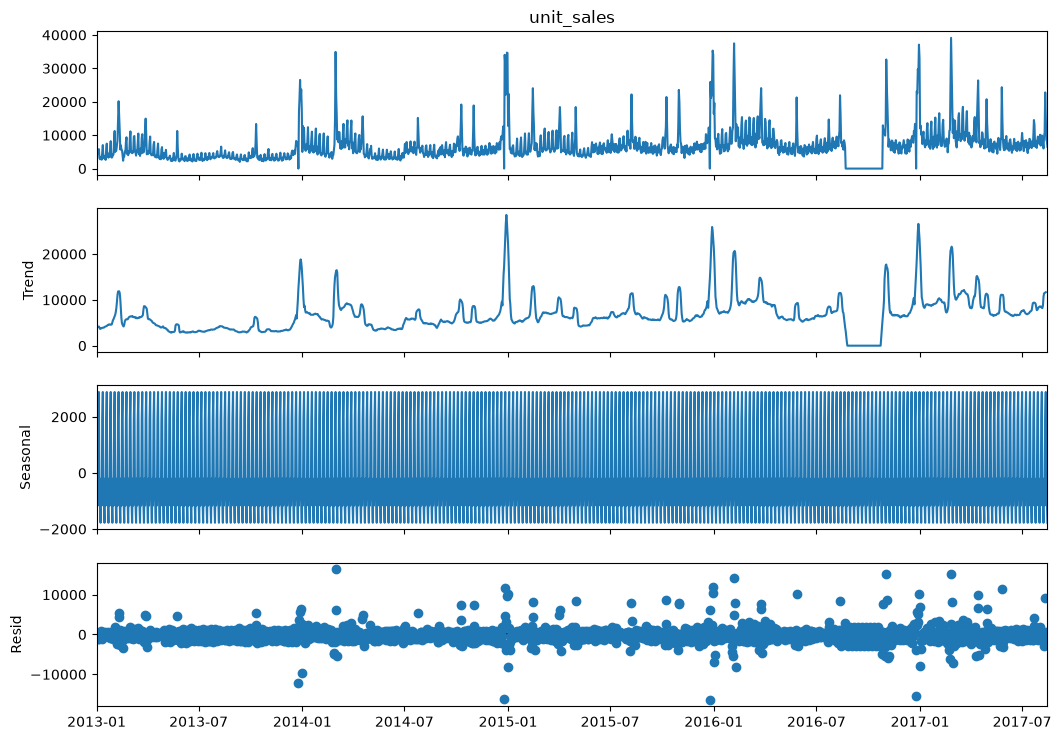

{'raw_train_rows': 125497040, 'observed_store25_days': 1618, 'regular_store25_days': 1688, 'residual_elements': 1688, 'residual_numeric': 1682, 'seasonal_elements': 1688, 'trend_numeric': 1682}
notebook_cell_2:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
{'statistic': -5.693928781556772, 'pvalue': 7.954000945744439e-07, 'usedlag': 21, 'nobs': 1666, 'critical': {'1%': np.float64(-3.4342812150354276), '5%': np.float64(-2.8632764080687307), '10%': np.float64(-2.5676944214132233)}, 'reject_unit_root_5percent': True}
Буквальный ряд groupby до календарного заполнения: {'source_elements': 1618, 'residual_elements': 1618, 'residual_numeric': 1612, 'seasonal_elements': 1618, 'trend_num

In [2]:
decomp = seasonal_decompose(s25, model='additive', period=7)
counts = {'raw_train_rows':meta['raw_rows'], 'observed_store25_days':len(observed25), 'regular_store25_days':len(s25), 'residual_elements':len(decomp.resid), 'residual_numeric':int(decomp.resid.notna().sum()), 'seasonal_elements':len(decomp.seasonal), 'trend_numeric':int(decomp.trend.notna().sum())}
print(counts)
assert len(decomp.resid)==len(s25) and decomp.resid.notna().sum()==len(s25)-6
assert np.allclose((decomp.trend+decomp.seasonal+decomp.resid).dropna(), s25.loc[decomp.resid.dropna().index])
fig=decomp.plot(); fig.set_size_inches(12,8); plt.show()
def adf_result(s):
    a=adfuller(s.dropna(), autolag='AIC')
    return {'statistic':float(a[0]), 'pvalue':float(a[1]), 'usedlag':int(a[2]), 'nobs':int(a[3]), 'critical':a[4], 'reject_unit_root_5percent':bool(a[1]<0.05)}
rezultaty['unit5']={'counts':counts,'adf_store25':adf_result(s25)}
print(rezultaty['unit5']['adf_store25'])
# Сверка с буквальным groupby из условия без календарного заполнения.
bare = seasonal_decompose(observed25, model='additive', period=7)
bare_counts = {'source_elements':len(observed25),'residual_elements':len(bare.resid),'residual_numeric':int(bare.resid.notna().sum()),'seasonal_elements':len(bare.seasonal),'trend_numeric':int(bare.trend.notna().sum())}
rezultaty['unit5']['counts_before_calendar_fill']=bare_counts
print('Буквальный ряд groupby до календарного заполнения:',bare_counts)


## Юнит 6. Последовательная проверка
Три тестовых отрезка содержат по 7 дней. Обучение каждого отрезка заканчивается до его теста; это проверяется утверждением в коде.

In [3]:
splits=[]
for train_idx,test_idx in TimeSeriesSplit(n_splits=3,test_size=7).split(s25):
    assert train_idx.max()<test_idx.min()
    splits.append({'train':len(train_idx),'test':len(test_idx),'last_train':str(s25.index[train_idx[-1]].date()),'first_test':str(s25.index[test_idx[0]].date())})
print(splits)
rezultaty['unit6']=splits
observed_splits=[{'train':len(a),'test':len(b)} for a,b in TimeSeriesSplit(n_splits=3,test_size=7).split(observed25)]
print('Размеры для исходного groupby без заполнения:',observed_splits)
rezultaty['unit6_original_groupby']=observed_splits


[{'train': 1667, 'test': 7, 'last_train': '2017-07-25', 'first_test': '2017-07-26'}, {'train': 1674, 'test': 7, 'last_train': '2017-08-01', 'first_test': '2017-08-02'}, {'train': 1681, 'test': 7, 'last_train': '2017-08-08', 'first_test': '2017-08-09'}]
Размеры для исходного groupby без заполнения: [{'train': 1597, 'test': 7}, {'train': 1604, 'test': 7}, {'train': 1611, 'test': 7}]


## Юнит 8. Окна и лаги
Скользящее среднее сглаживает ряд, стандартное отклонение показывает разброс. Линии Боллинджера здесь равны среднему за 30 дней плюс/минус три стандартных отклонения. Экспоненциальное среднее сильнее учитывает недавние наблюдения; span задаёт характерный размер памяти.
Эти графики описательные: включают текущий день. Для будущего прогноза текущие продажи использовать нельзя. Лаг сдвигает прошлое значение на более позднюю строку.

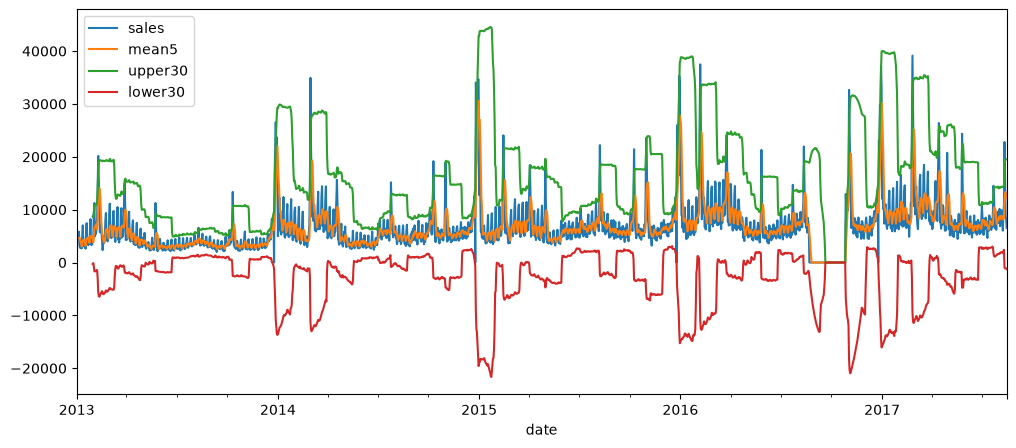

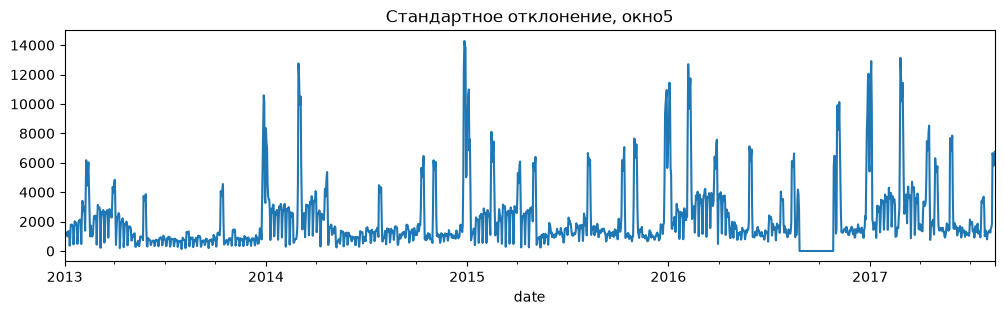

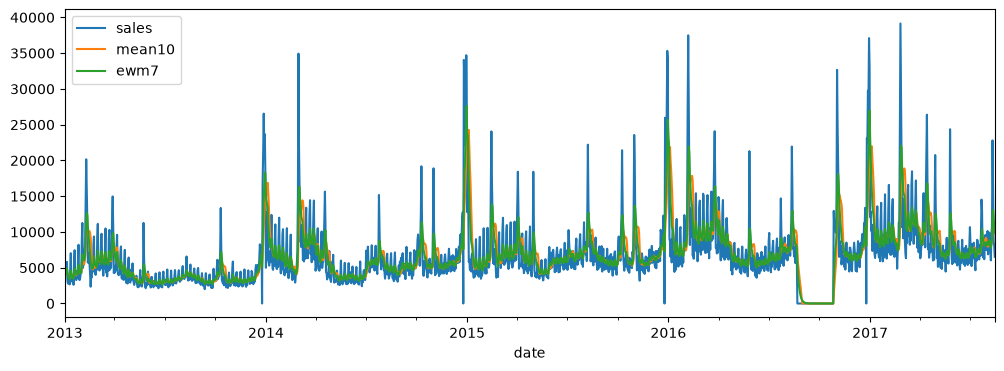

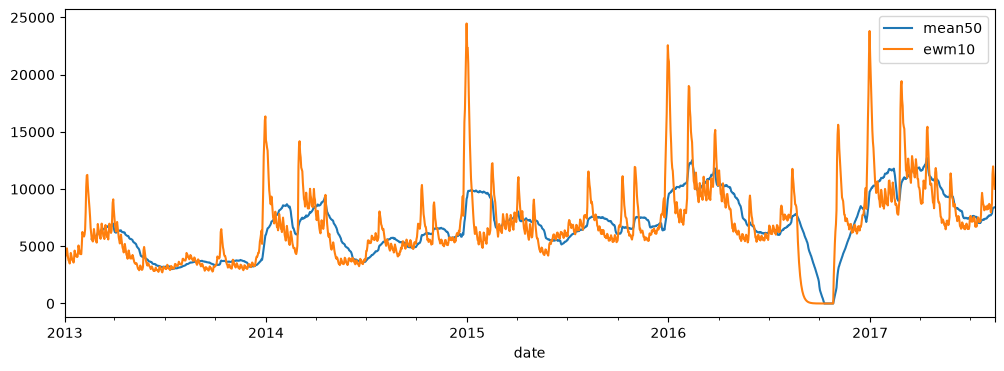

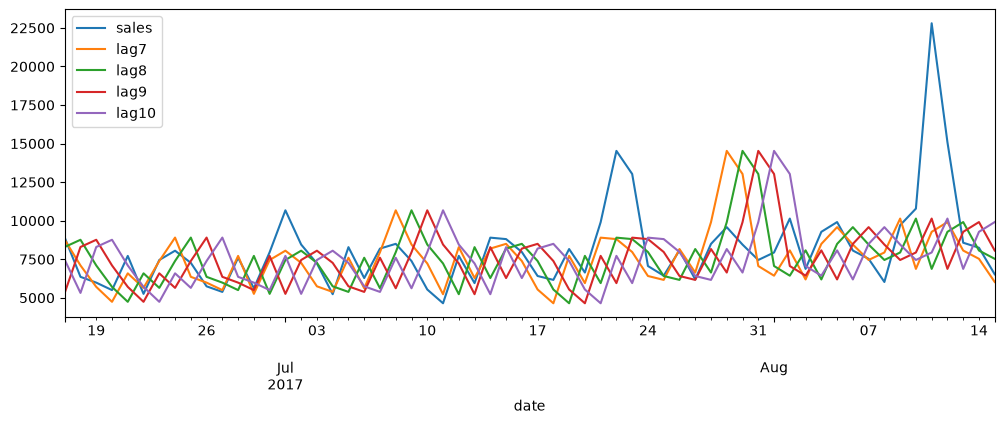

Индексы пересечений (с0): [50, 52, 56, 60, 63, 67, 69, 74, 75, 81, 82, 86, 97, 143, 147, 180, 181, 186, 188, 193, 238, 242, 244, 274, 293, 305, 306, 333, 338, 339, 380, 382, 383, 423, 455, 473, 474, 523, 524, 536, 539, 542, 582, 613, 615, 620, 630, 631, 632, 634, 657, 668, 675, 698, 700, 704, 705, 711, 739, 774, 785, 788, 790, 795, 798, 802, 804, 809, 811, 816, 818, 821, 832, 850, 854, 885, 926, 927, 940, 941, 960, 963, 964, 1005, 1022, 1032, 1042, 1081, 1105, 1130, 1140, 1144, 1148, 1152, 1154, 1159, 1160, 1178, 1190, 1194, 1195, 1242, 1252, 1278, 1281, 1284, 1288, 1292, 1329, 1378, 1428, 1450, 1471, 1474, 1475, 1515, 1533, 1536, 1540, 1544, 1546, 1563, 1569, 1579, 1582, 1606, 1610, 1614, 1616, 1643, 1645, 1656]
Даты пересечений: ['2013-02-20', '2013-02-22', '2013-02-26', '2013-03-02', '2013-03-05', '2013-03-09', '2013-03-11', '2013-03-16', '2013-03-17', '2013-03-23', '2013-03-24', '2013-03-28', '2013-04-08', '2013-05-24', '2013-05-28', '2013-06-30', '2013-07-01', '2013-07-06', '2013-

In [4]:
f=pd.DataFrame({'sales':s25})
f['mean5']=s25.rolling(5).mean(); f['std5']=s25.rolling(5).std()
f['mean30']=s25.rolling(30).mean(); f['upper30']=f.mean30+3*s25.rolling(30).std(); f['lower30']=f.mean30-3*s25.rolling(30).std()
f[['sales','mean5','upper30','lower30']].plot(figsize=(12,5));plt.show()
f.std5.plot(title='Стандартное отклонение, окно5',figsize=(12,3));plt.show()
f['mean10']=s25.rolling(10).mean();f['ewm7']=s25.ewm(span=7,adjust=True).mean()
f[['sales','mean10','ewm7']].plot(figsize=(12,4));plt.show()
f['midrange10']=s25.rolling(10).apply(lambda values:(np.max(values)+np.min(values))/2,raw=True)
assert np.allclose(f.midrange10.dropna(), ((s25.rolling(10).max()+s25.rolling(10).min())/2).dropna())
f['mean50']=s25.rolling(50).mean();f['ewm10']=s25.ewm(span=10,adjust=True).mean()
signs=np.sign(f.mean50-f.ewm10);changes=signs.diff();crossings=changes.notna() & changes.ne(0)
indices=np.flatnonzero(crossings).tolist();dates=f.index[crossings].strftime('%Y-%m-%d').tolist()
print('Индексы пересечений (с0):',indices);print('Даты пересечений:',dates)
f[['mean50','ewm10']].plot(figsize=(12,4));plt.show()
for lag in range(7,11):f[f'lag{lag}']=s25.shift(lag)
f[['sales','lag7','lag8','lag9','lag10']].iloc[-60:].plot(figsize=(12,4));plt.show()
f.to_csv(P/'faktory_magazin25.csv')
rezultaty['unit8']={'crossing_indices':indices,'crossing_dates':dates,'first_valid_rolling23_index':int(pd.Series(range(100)).rolling(23).mean().first_valid_index())}
# Независимо проверяем текстовый ответ8.4 и эквивалентность shift() / shift(1).
df=pd.DataFrame({'value':np.arange(100,dtype=float),'target':np.arange(100,dtype=float)})
assert np.allclose(df.value.rolling(window=50).apply(np.mean).dropna(),df.value.rolling(50).mean().dropna())
assert df.target.shift().equals(df.target.shift(1))
print('Окно23: первый индекс22, то есть23-й элемент. shift() равен shift(1).')

## Юнит 10. Товар 103501: прогнозирование
Оставляем ровно последний 1 день для окончательного теста, как разрешено условием 1–2 дня. Поэтому лаги 1…6 доступны в момент прогноза и утечки будущего нет. Скользящее среднее берёт шесть предыдущих дней.
Параметры ARIMA выбираются только по обучению: d по тесту единичного корня, p/q из небольшой сетки 0…2 по AIC (критерий компромисса качества и сложности). Один тестовый день — слабое свидетельство качества; сравнение учебное, для эксплуатации нужна проверка многих отрезков.

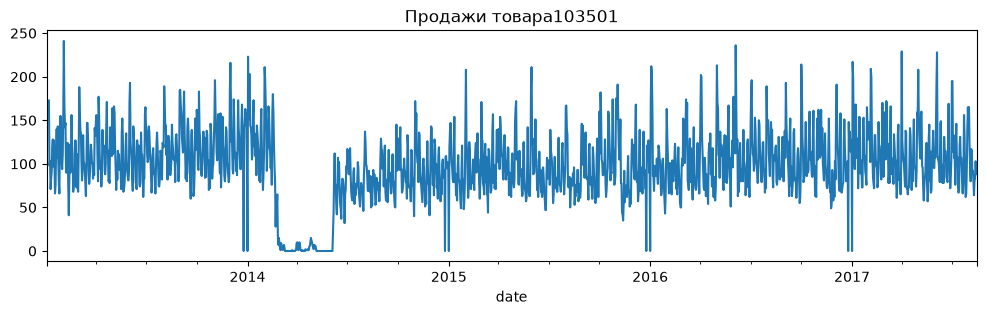

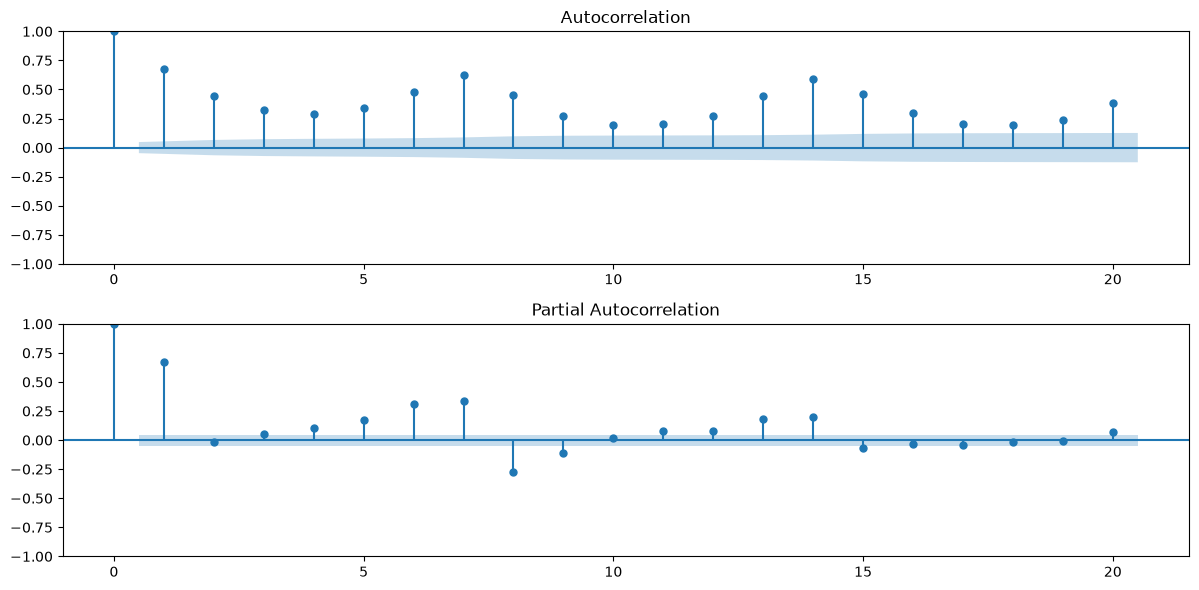

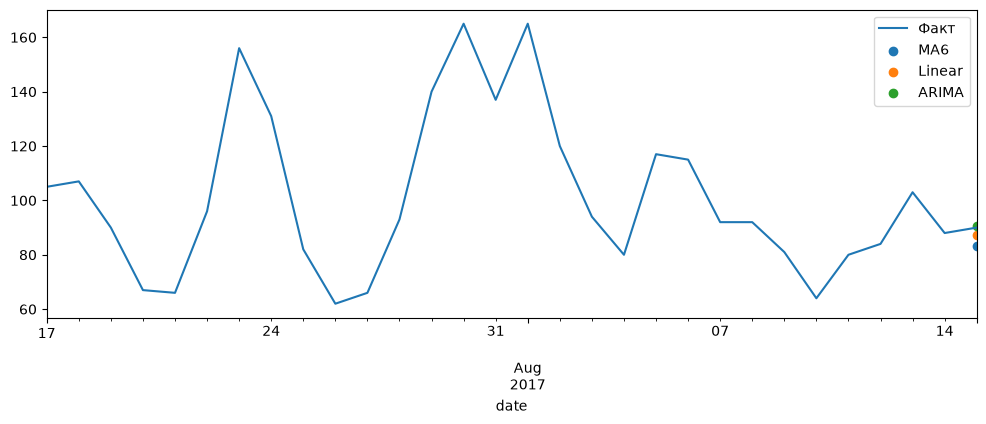

notebook_cell_2:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
ADF на обучении: {'statistic': -3.288631363871889, 'pvalue': 0.015394364255746432, 'usedlag': 25, 'nobs': 1660, 'critical': {'1%': np.float64(-3.4342954463097706), '5%': np.float64(-2.8632826898390484), '10%': np.float64(-2.5676977663666714)}, 'reject_unit_root_5percent': True}
   p  d  q           aic  converged
0  0  0  0  17312.543882       True
1  0  0  1  16581.187397       True
2  0  0  2  16384.273012       True
3  1  0  0  16291.744573       True
4  1  0  1  16293.188807       True
5  1  0  2  16178.359680       True
6  2  0  0  16293.279553       True
7  2  0  1  16284.031702       True
8  2  0  2  16284.833

In [5]:
train_item=item.iloc[:-1];test_item=item.iloc[-1:]
adf_item=adf_result(train_item); d=0 if adf_item['reject_unit_root_5percent'] else 1
print('ADF на обучении:',adf_item)
plt.figure(figsize=(12,3));item.plot(title='Продажи товара103501');plt.show()
fig,ax=plt.subplots(2,1,figsize=(12,6));plot_acf(train_item.diff(d).dropna() if d else train_item,lags=20,ax=ax[0]);plot_pacf(train_item.diff(d).dropna() if d else train_item,lags=20,ax=ax[1]);plt.tight_layout();plt.show()
lagged=pd.DataFrame({'y':item})
for lag in range(1,7):lagged[f'lag{lag}']=item.shift(lag)
lagged=lagged.dropna();tr=lagged.iloc[:-1];te=lagged.iloc[-1:]
reg=LinearRegression().fit(tr.drop(columns='y'),tr.y)
pred_lr=reg.predict(te.drop(columns='y'));pred_ma=np.array([train_item.iloc[-6:].mean()])
assert np.isclose(te.lag1.iloc[0],train_item.iloc[-1])
candidates=[];models={}
for pp in range(3):
    for qq in range(3):
        with warnings.catch_warnings(record=True) as ww:
            fit=ARIMA(train_item,order=(pp,d,qq)).fit()
        candidates.append({'p':pp,'d':d,'q':qq,'aic':float(fit.aic),'converged':bool(fit.mle_retvals.get('converged',True))})
        models[(pp,d,qq)]=fit
eligible=[c for c in candidates if c['converged']]
best=min(eligible,key=lambda x:x['aic']);chosen=models[(best['p'],d,best['q'])];pred_arima=chosen.forecast(1)
comparison={'moving_average6':metrics(test_item,pred_ma),'linear_lags1_6':metrics(test_item,pred_lr),'ARIMA':metrics(test_item,pred_arima)}
print(pd.DataFrame(candidates));print('Выбрано:',best);print(pd.DataFrame(comparison).T)
plt.figure(figsize=(12,4));item.iloc[-30:].plot(label='Факт')
for label,v in [('MA6',pred_ma),('Linear',pred_lr),('ARIMA',pred_arima)]:plt.scatter(test_item.index,v,label=label)
plt.legend();plt.show()
rezultaty['unit10']={'adf':adf_item,'candidates':candidates,'selected':best,'metrics':comparison,'forecast_date':str(test_item.index[0].date()),'actual':test_item.tolist(),'forecasts':{'MA6':list(pred_ma),'Linear':list(pred_lr),'ARIMA':list(pred_arima)}}

## Юнит 12. Prophet: годовой прогноз, настройка, праздники
Prophet объединяет тренд, сезонность и праздничные эффекты. Для честного сравнения последний 365-дневный отрезок оставлен тестом; последние 180 дней более раннего обучения используются для выбора гибкости тренда. Увеличение changepoint_prior_scale разрешает тренду сильнее изгибаться; выбор делаем по проверочному отрезку, не по будущему тесту.
RMSE — корень средней квадратичной ошибки; это ошибка в единицах продаж. У настоящих будущих 365 дней нет факта, поэтому их RMSE вычислить нельзя. Для них строим отдельный прогноз после обучения на всей доступной истории.

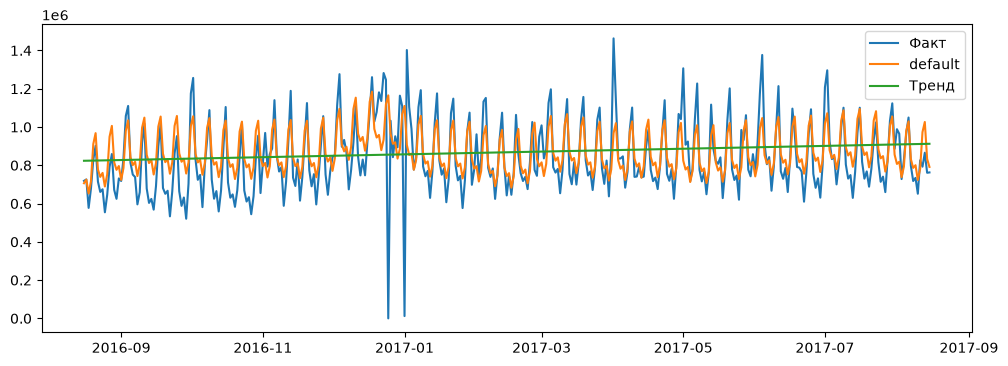

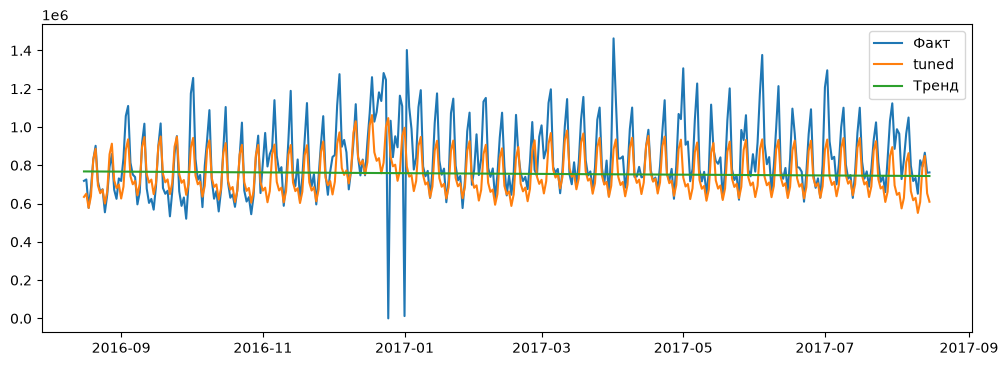

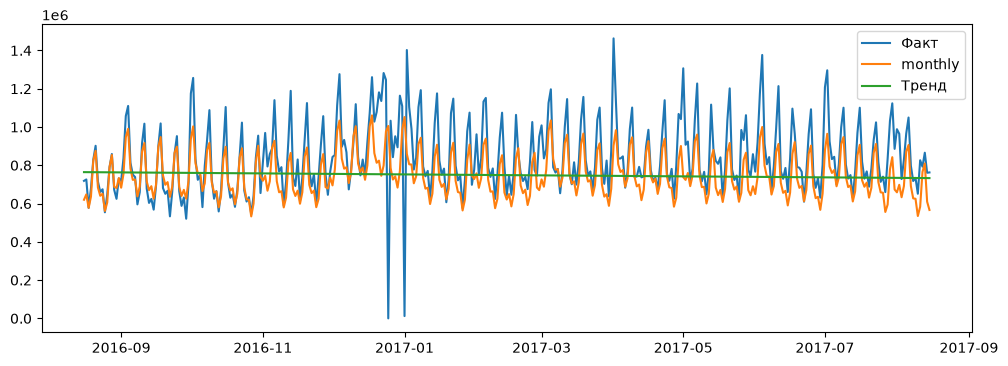

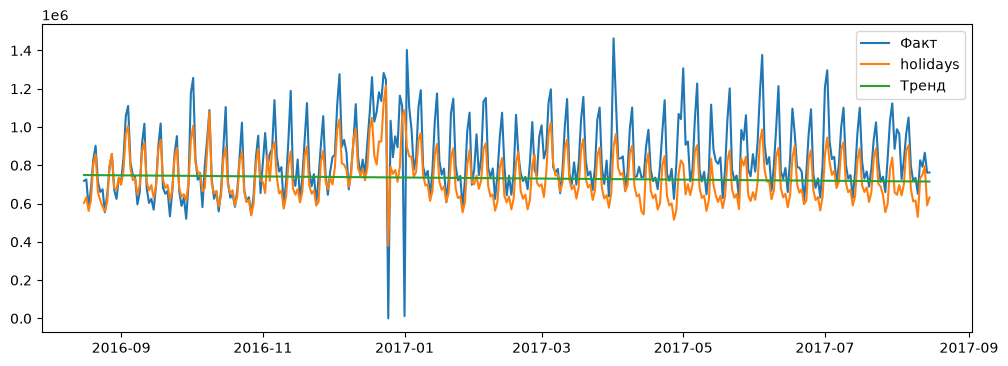

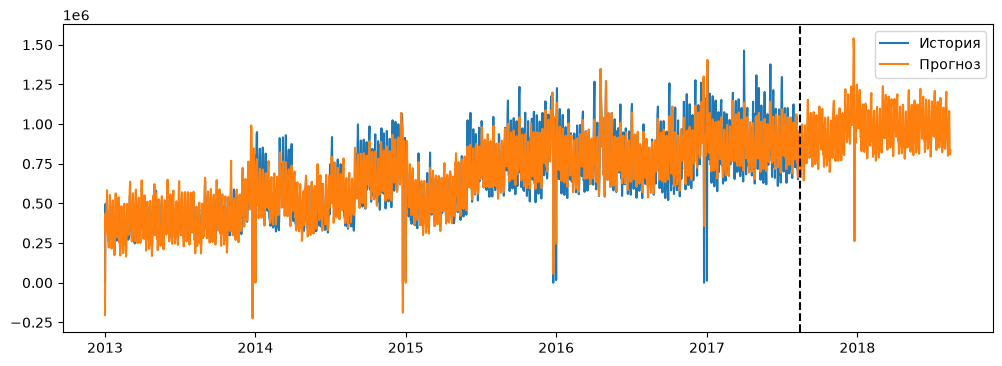

00:35:11 - cmdstanpy - INFO - Chain [1] start processing
00:35:12 - cmdstanpy - INFO - Chain [1] done processing
00:35:12 - cmdstanpy - INFO - Chain [1] start processing
00:35:12 - cmdstanpy - INFO - Chain [1] done processing
00:35:13 - cmdstanpy - INFO - Chain [1] start processing
00:35:14 - cmdstanpy - INFO - Chain [1] done processing
00:35:14 - cmdstanpy - INFO - Chain [1] start processing
00:35:15 - cmdstanpy - INFO - Chain [1] done processing
00:35:16 - cmdstanpy - INFO - Chain [1] start processing
00:35:16 - cmdstanpy - INFO - Chain [1] done processing
   scale     train_rmse  validation_rmse
0   0.05  105995.319916    152770.937407
1   0.10  103269.289967    148820.939273
2   0.50   95490.526791    129299.005483
3   1.00   94724.534743    170890.749737
4   2.50   93537.289811    185350.988143
Выбранная гибкость тренда: 0.5
00:35:17 - cmdstanpy - INFO - Chain [1] start processing
00:35:17 - cmdstanpy - INFO - Chain [1] done processing
00:35:18 - cmdstanpy - INFO - Chain [1] start

In [6]:
from prophet import Prophet
holidays_raw=pd.read_csv(io.StringIO(embedded_text('holidays_events.csv')),parse_dates=['date'])
holidays_frame=holidays_raw.loc[~holidays_raw.transferred,['description','date']].rename(columns={'description':'holiday','date':'ds'}).drop_duplicates()
data=all_sales.rename('y').rename_axis('ds').reset_index()
train_prophet=data.iloc[:-365].copy();test_prophet=data.iloc[-365:].copy()
fit_part=train_prophet.iloc[:-180];validation=train_prophet.iloc[-180:]
scales=[0.05,0.1,0.5,1.0,2.5];scale_scores=[]
def prophet_fit(frame,scale,monthly=False,holidays=False):
    m=Prophet(changepoint_prior_scale=scale,holidays=holidays_frame if holidays else None,uncertainty_samples=0)
    if monthly:m.add_seasonality(name='monthly',period=30.5,fourier_order=5)
    m.fit(frame,seed=42)
    return m
for scale in scales:
    m=prophet_fit(fit_part,scale)
    valpred=m.predict(validation[['ds']]).yhat
    scale_scores.append({'scale':scale,'train_rmse':metrics(fit_part.y,m.predict(fit_part[['ds']]).yhat)['RMSE'],'validation_rmse':metrics(validation.y,valpred)['RMSE']})
selected_scale=min(scale_scores,key=lambda s:s['validation_rmse'])['scale']
print(pd.DataFrame(scale_scores));print('Выбранная гибкость тренда:',selected_scale)
pmetrics={};ppreds={};ptrends={}
for label,scale,monthly,holidays_flag in [('default',0.05,False,False),('tuned',selected_scale,False,False),('monthly',selected_scale,True,False),('holidays',selected_scale,True,True)]:
    m=prophet_fit(train_prophet,scale,monthly,holidays_flag)
    forecast=m.predict(test_prophet[['ds']]);pmetrics[label]=metrics(test_prophet.y,forecast.yhat);ppreds[label]=forecast.yhat.to_numpy();ptrends[label]=forecast.trend.to_numpy()
    plt.figure(figsize=(12,4));plt.plot(test_prophet.ds,test_prophet.y,label='Факт');plt.plot(test_prophet.ds,forecast.yhat,label=label);plt.plot(test_prophet.ds,forecast.trend,label='Тренд');plt.legend();plt.show()
print(pd.DataFrame(pmetrics).T)
# Фиксируем модель с месячной сезонностью/праздниками из условия и строим настоящий будущий год.
full_model=prophet_fit(data,selected_scale,True,True)
future=full_model.make_future_dataframe(periods=365,freq='D');full_forecast=full_model.predict(future)
assert len(full_forecast)==len(data)+365
full_forecast[['ds','yhat','trend']].to_csv(P/'prophet_prognoz365.csv',index=False)
plt.figure(figsize=(12,4));plt.plot(data.ds,data.y,label='История');plt.plot(full_forecast.ds,full_forecast.yhat,label='Прогноз');plt.axvline(data.ds.max(),color='black',linestyle='--');plt.legend();plt.show()
rezultaty['unit12']={'scale_validation':scale_scores,'selected_scale':selected_scale,'test_days':365,'metrics':pmetrics,'future_days':365,'monthly_improved':bool(pmetrics['monthly']['RMSE']<pmetrics['tuned']['RMSE']),'holidays_improved':bool(pmetrics['holidays']['RMSE']<pmetrics['monthly']['RMSE'])}
print('Месячная сезонность улучшила RMSE:',rezultaty['unit12']['monthly_improved']);print('Праздники улучшили RMSE:',rezultaty['unit12']['holidays_improved'])

## Юнит 14. XGBoost и CatBoost: календарь, праздники, лаги
Обе модели складывают много небольших деревьев решений. Берём последние 30 дней в тест и одинаковые строки для всех вариантов, чтобы сравнение было честным. Количество деревьев фиксировано заранее; тест не используется для ранней остановки или подбора настроек.
Лаги 31,60,365 доступны сразу для всего 30-дневного горизонта. Флаг праздника вычисляется из календаря, известного заранее. Дни региональных праздников могут затрагивать лишь часть магазинов; мы используем общий индикатор для агрегированных продаж и описываем это ограничение.

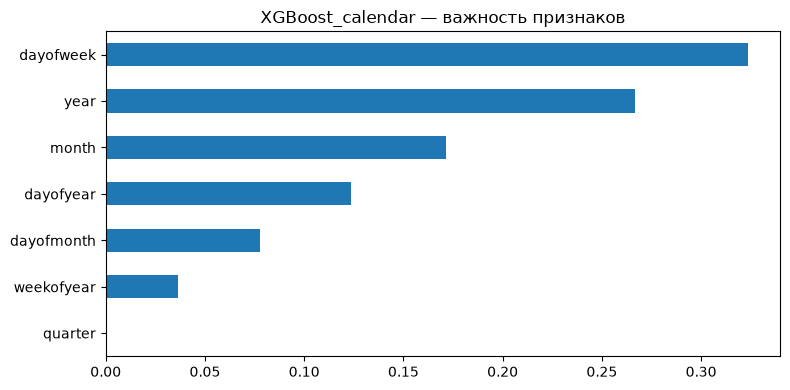

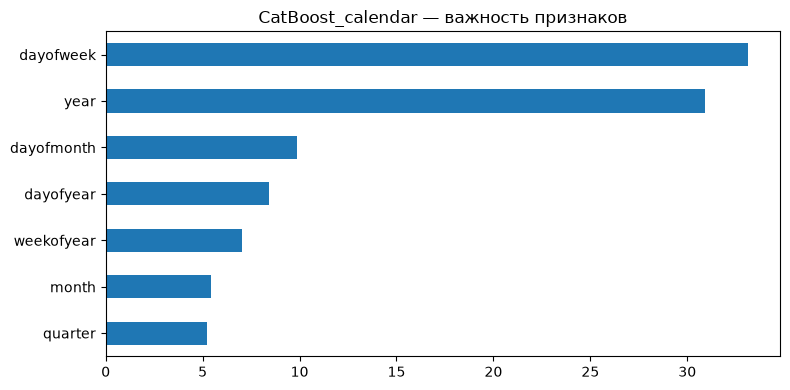

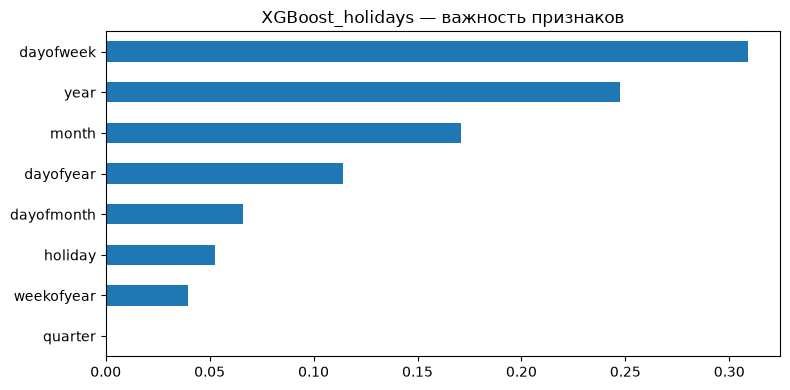

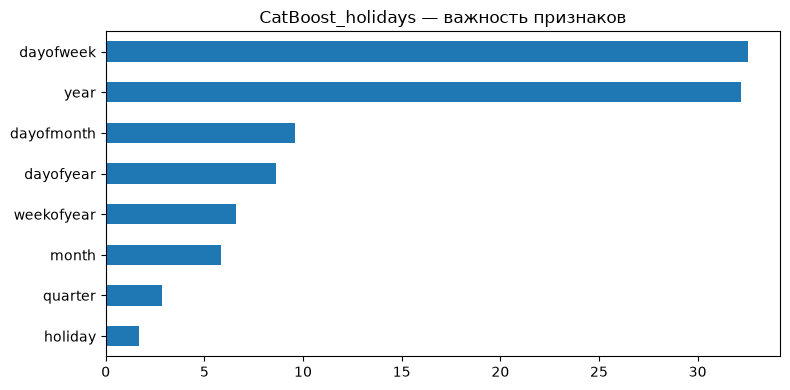

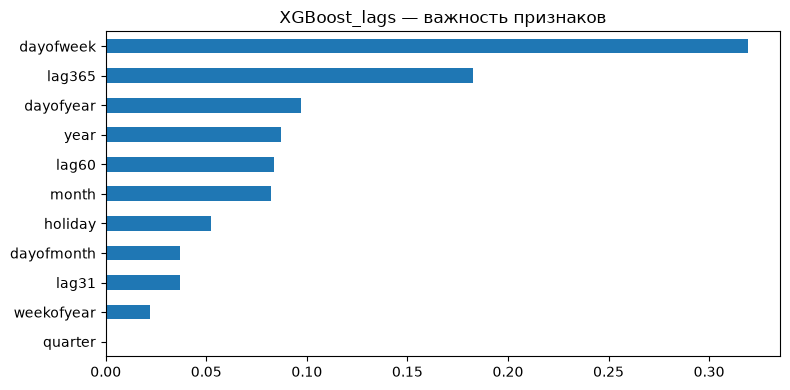

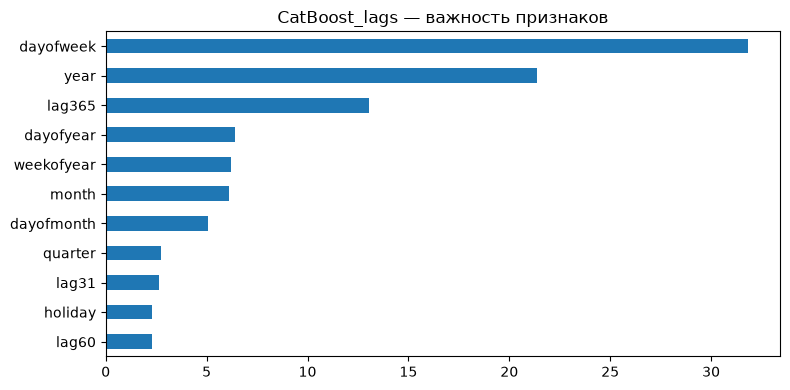

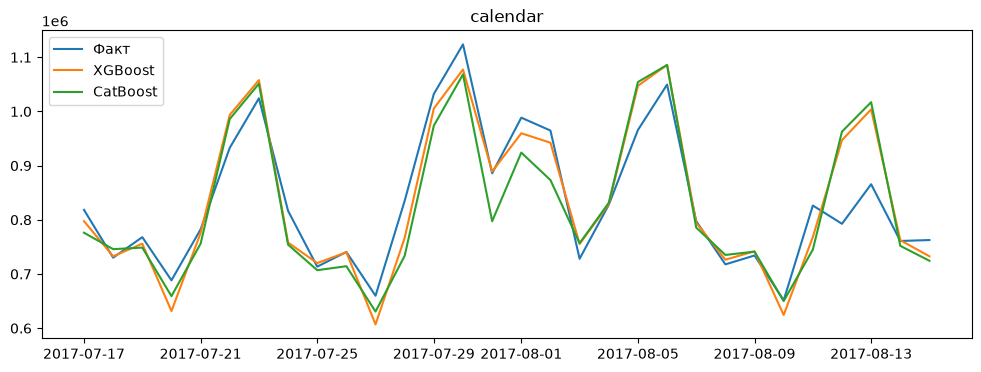

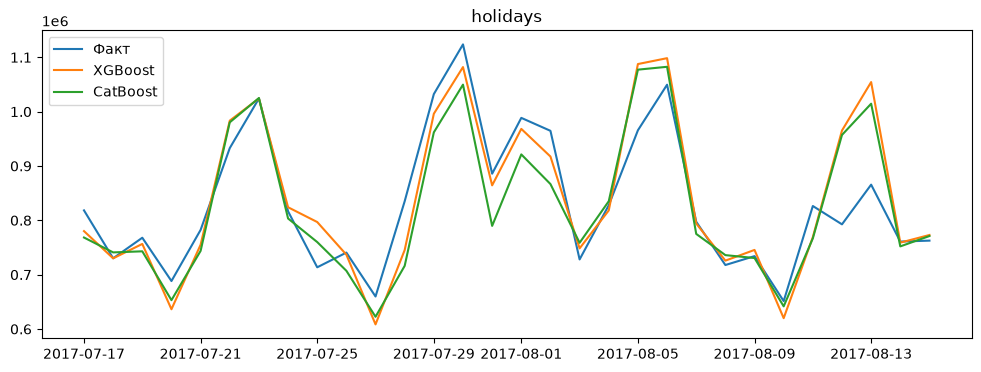

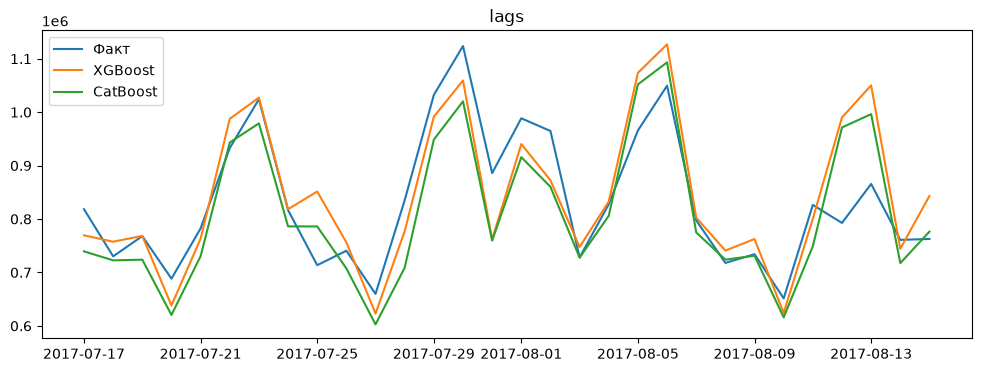

                            MAE  ...  zero_targets_excluded_from_MAPE
XGBoost_calendar   36104.824400  ...                              0.0
CatBoost_calendar  48081.091868  ...                              0.0
XGBoost_holidays   42260.607400  ...                              0.0
CatBoost_holidays  49651.575700  ...                              0.0
XGBoost_lags       54070.643850  ...                              0.0
CatBoost_lags      59300.647029  ...                              0.0

[6 rows x 5 columns]


In [7]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
dates=all_sales.index
X=pd.DataFrame(index=dates)
X['year']=dates.year;X['month']=dates.month;X['dayofweek']=dates.dayofweek;X['dayofmonth']=dates.day;X['dayofyear']=dates.dayofyear;X['quarter']=dates.quarter;X['weekofyear']=dates.isocalendar().week.astype(int)
calendar_cols=list(X.columns)
X['holiday']=dates.isin(pd.DatetimeIndex(holidays_frame.ds)).astype(int)
for lag in [31,60,365]:X[f'lag{lag}']=all_sales.shift(lag)
X=X.dropna();y=all_sales.loc[X.index];cut=len(X)-30
assert X.index[cut-1]<X.index[cut]
assert X.index[-1]-pd.Timedelta(days=31)<X.index[cut]
# Все сравнения используют одинаковую историю; календарная база также обрезана после365 дней.
tree_metrics={};importance={};tree_predictions={}
for variant,columns in [('calendar',calendar_cols),('holidays',calendar_cols+['holiday']),('lags',list(X.columns))]:
    for label,model in [('XGBoost',XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,random_state=42,n_jobs=2,objective='reg:squarederror')),('CatBoost',CatBoostRegressor(iterations=300,depth=5,learning_rate=0.05,random_seed=42,thread_count=2,verbose=False,allow_writing_files=False))]:
        model.fit(X[columns].iloc[:cut],y.iloc[:cut])
        pred=model.predict(X[columns].iloc[cut:]);key=label+'_'+variant
        tree_metrics[key]=metrics(y.iloc[cut:],pred);tree_predictions[key]=pred
        importance[key]=dict(zip(columns,map(float,model.feature_importances_)))
        pd.Series(importance[key]).sort_values().plot.barh(title=key+' — важность признаков',figsize=(8,4));plt.tight_layout();plt.show()
print(pd.DataFrame(tree_metrics).T)
for variant in ['calendar','holidays','lags']:
    plt.figure(figsize=(12,4));plt.plot(y.index[-30:],y.iloc[-30:],label='Факт')
    for label in ['XGBoost','CatBoost']:plt.plot(y.index[-30:],tree_predictions[label+'_'+variant],label=label)
    plt.title(variant);plt.legend();plt.show()
rezultaty['unit14']={'train_days':cut,'test_days':30,'lags':[31,60,365],'metrics':tree_metrics,'feature_importance':importance}

## Независимые проверки и выводы
Проверяем метрики второй реализацией из scikit-learn, суммы полных агрегатов и хронологию. Маленькая ошибка на одном отрезке не доказывает универсальное превосходство модели. Ни один учебный прогноз не используется для реальных покупок или торговли.

In [8]:
assert np.isclose(all_sales.sum(),meta['raw_sum'])
for key,pred in tree_predictions.items():
    mm=tree_metrics[key]
    assert np.isclose(mm['MAE'],mean_absolute_error(y.iloc[-30:],pred))
    assert np.isclose(mm['MSE'],mean_squared_error(y.iloc[-30:],pred))
    nz=y.iloc[-30:]!=0
    assert np.isclose(mm['MAPE_percent_nonzero'],100*mean_absolute_percentage_error(y.iloc[-30:][nz],np.asarray(pred)[nz]))
for label,pred in ppreds.items():
    assert np.isclose(pmetrics[label]['RMSE'],np.sqrt(mean_squared_error(test_prophet.y,pred)))
print('Лучшая модель на единственном тестовом дне:',min(comparison,key=lambda k:comparison[k]['MAE']))
for name in ['XGBoost','CatBoost']:
    print(name,'RMSE:',{v:tree_metrics[name+'_'+v]['RMSE'] for v in ['calendar','holidays','lags']})
    print(name,'главные признаки:',sorted(importance[name+'_lags'],key=importance[name+'_lags'].get,reverse=True)[:3])
print('Все проверки сумм, хронологии, метрик выполнены.')
(P/'vychisleniya_proekta.json').write_text(json.dumps(rezultaty,ensure_ascii=False,indent=2),encoding='utf8')

Лучшая модель на единственном тестовом дне: ARIMA
XGBoost RMSE: {'calendar': 51859.09514827547, 'holidays': 63035.17799689573, 'lags': 74316.2515460335}
XGBoost главные признаки: ['dayofweek', 'lag365', 'dayofyear']
CatBoost RMSE: {'calendar': 63429.2026805154, 'holidays': 65674.2404700636, 'lags': 73647.5120500559}
CatBoost главные признаки: ['dayofweek', 'year', 'lag365']
Все проверки сумм, хронологии, метрик выполнены.


## Письменные выводы по реальным результатам

- **Исходные данные.** Полный train.csv содержит 125497040 строк. После группировки магазин 25 имеет 1618 наблюдаемых дат; регулярный календарь —1688 дней. В буквальном ряду из условия длины исходника, остатка и сезонности равны 1618, числовых остатков/тренда 1612. В календарном варианте длины 1688 и 1682 соответственно. Различие вызвано явно описанным заполнением 70 дней без записей нулями.
- **Стационарность.** Для календарного ряда магазина 25 тест отверг единичный корень (p≈0.0000007954). Это не утверждение о полном отсутствии сезонности. На графике видны регулярные колебания и отдельные провалы; сезонная неделя помогает отделить повторение от остатка.
- **Проверка времени.** Для буквального исходного ряда размеры обучения 1597,1604,1611, теста по 7; для календарного 1667,1674,1681. Во всех случаях обучение строго раньше теста.
- **Товар 103501.** ADF по обучению дал p≈0.01539; выбрано d=0. По AIC из рассмотренной сетки выбрана ARIMA(1,0,2). На последнем дне факт 90, прогнозы: среднее 83.3333, линейная модель 87.2621, ARIMA90.5489; соответственно MAE6.6667,2.7379,0.5489. Победа ARIMA здесь относится к одному дню и не переносится автоматически на другие даты.
- **Гибкость Prophet.** На проверочных 180 днях лучшим оказалсякоэффициент 0.5: RMSE129299.01 против 152770.94 при 0.05. Движение от 0.05 к 0.5 помогло, но дальнейшее увеличение до 1 и 2.5 ухудшило проверку при снижении ошибки обучения — признак переобучения слишком гибкого тренда. На отдельном 365-дневном тесте настройка не улучшила базовый результат: RMSE141800.34 у default против 161703.73 у tuned. Это честный пример несовпадения валидации и теста.
- **Дополнительные компоненты Prophet.** Месячная сезонность снизила RMSE настроенной модели до 160038.32; праздники — до 158035.24. Это улучшение относительно tuned, но базовая модель на том же тесте всё ещё лучше. Окончательный будущий год показан без метрики, поскольку будущих фактов нет.
- **Деревья.** На 30-дневном тесте календарный XGBoost дал MAE36104.82, MAPE4.31%, MSE2689365749.60; календарный CatBoost —MAE48081.09, MAPE5.61%, MSE4023263752.69. День недели и год — главные календарные признаки. Добавление праздничного индикатора и выбранных лагов здесь ухудшило обе модели: RMSE XGBoost51859.10→63035.18→74316.25, CatBoost63429.20→65674.24→73647.51. В итоговых моделях с лагами важны день недели и lag365; важность не означает причинность и не гарантирует улучшение.
- **Практический итог.** Для данного контрольного отрезка разумно сохранить простую календарную модель XGBoost как базу, а новые признаки оценивать на нескольких более ранних проверочных периодах. Дополнительные факторы не объявляются полезными вопреки реальным метрикам.


## Ограничения
1. Пропущенные календарные дни заполнены нулями как явное допущение; при наличии отдельного календаря закрытия магазинов его следует проверить.
2. MAPE не определена при нулевом факте: такие дни исключены только из этой метрики, их количество напечатано. MAE/MSE используют все дни.
3. Графики и сравнения относятся только к этим историческим данным и выбранным отрезкам. У настоящего будущего 365-дневного прогноза метрики пока отсутствуют.
4. Праздники и месячная сезонность не обязаны улучшать качество: фактическое изменение показано в таблицах.
5. Менторская проверка и публикация выполняются отдельно; этот файл не доказывает принятие проекта платформой.